<a href="https://colab.research.google.com/github/IrynaKiriienko/Python_projects/blob/main/Analysis%20of%20sales%20of%20goods%20for%20the%20period.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount("/content/drive")

%cd /content/drive/MyDrive/Colab/Module_Task

sales= pd.read_csv("events.csv")
products = pd.read_csv("products.csv")
countries = pd.read_csv("countries.csv")

Mounted at /content/drive
/content/drive/MyDrive/Colab/Module_Task


## Таблиця events містить такі поля:
*   Order ID	- код замовлення
*   Order Date	- дата замовлення
*   Ship Date	- дата відвантаження товару
*   Order Priority	- пріорітет замовлення
*   Country Code	- код країни
*   Product ID	- код продукту
*   Sales Channel	- тип продажу
*   Units Sold	- кількість проданого товару
*   Unit Price	- ціна товару
*   Unit Cost - собівартість товару

##Таблиця countries містить такі поля:
*   name
*   alpha-2
*   alpha-3
*   region
*   sub-region

## Таблиця products містить такі поля:


*   id
*   item_type

## Ключові поля для поєднання:
Таблиця events:
*  Country Code	- код країни
*  Product ID	- код продукту

Таблиця countries:
*   alpha-3

Таблиця products:
*   id

# Аналіз наявності пропущених значеннь у кожній таблиці

In [ ]:
sales.info()
products.info()
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
mem

У таблиці countries є одне пропущене значення для Antarctica

У таблиці events у колонці Country Code є 82 пропущених значення. Скоріш за все це пов'язано з відсутністю кода країни для Antarctica. Пропоную також присвоїти значення Unknown. У колонці Units Sold є 2 пропущених значення, скоріш за все це або технічна помилка, або збій у створенні ордеру.





# Робота з пропущеними значеннями


У таблиці countries пропущенному значенню можна присвоїти значення Unknown, або взагалі видалити, тому що нам достовірно не відомом чи дійсно у таблиці events ордери, яким ми поставимо код країни Unknown дійсно були зроблені з Antarctica.

У таблиці events у колонці Country Code можна присвоїти значення Unknown, видалення цих значень буде сильно впливати на дані, тому що їх відсоток складає 6,17%.
А рядки з колонки Units Sold пропоную видалити або ж прорахувати та підставити медіанне значення для відповідної категорії товару. Але медіана буде доцільною для більшої кількості пропущених даних, а в нашому випадку їх відсоток становить лише 0,15%, тому доцільніше буде видалити ці дані для прискорення обробки інформації та розрахунку.

In [ ]:
sales["Country Code"] = sales["Country Code"].fillna("Unknown")
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1330 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
sales = sales.dropna(subset = ["Units Sold"])
sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1328 non-null   int64  
 1   Order Date      1328 non-null   object 
 2   Ship Date       1328 non-null   object 
 3   Order Priority  1328 non-null   object 
 4   Country Code    1328 non-null   object 
 5   Product ID      1328 non-null   int64  
 6   Sales Channel   1328 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1328 non-null   float64
 9   Unit Cost       1328 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 114.1+ KB


# Аналіз даних на коректність, за потреби перетворння типів даних на відповідні

Деякі дані розпізнані некоректно

Order Date - object, має бути date

Ship Date - object, має бути date

In [ ]:
sales["Order Date"] = pd.to_datetime(sales["Order Date"], format="%m/%d/%Y")
sales["Ship Date"] = pd.to_datetime(sales["Ship Date"], format="%m/%d/%Y")
sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   float64       
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 114.1+ KB


# Аналіз даних на наявність дублікатів.


In [ ]:
#Тут прибрала всі разрахунки, де не підтверджені дублікати або помилки з регістром.
unique_sales = sales["Sales Channel"].unique()
print (unique_sales)

['Online' 'Offline' 'online']


In [ ]:
sales["Sales Channel"] = sales["Sales Channel"].str.replace("online", "Online")
unique_sales = sales["Sales Channel"].unique()
print (unique_sales)

['Online' 'Offline']


# Аналіз на наявність аномалій

In [ ]:
# Перевіряємо значення на наявність аномалій у вигляді таблиці

sales.describe()


,Order ID,Order Date,Ship Date,Product ID,Units Sold,Unit Price,Unit Cost
count,1.328000e+03,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,5787.775602,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573496e+08,NaN,NaN,2820.635702,2905.198996,217.386320,176.187801


In [ ]:
# перевіряємо різницю між Order Date та Ship Date
sales["difference_date"] = sales["Ship Date"] - sales["Order Date"]
sales["difference_date"] = sales["difference_date"].astype(str)
sales["difference_date"] = sales["difference_date"].str.split(" ").str[0]
sales["difference_date"] = sales["difference_date"].astype(int)
sales["difference_date"].info()

<class 'pandas.core.series.Series'>
Index: 1328 entries, 0 to 1329
Series name: difference_date
Non-Null Count  Dtype
--------------  -----
1328 non-null   int64
dtypes: int64(1)
memory usage: 20.8 KB


In [ ]:
# Порахуємо прибуток і подивимось чи нема від'ємних значень, тим самим дамо відповідь чи не збиткові продажі.
sales["Profit"] = (sales["Unit Price"] - sales["Unit Cost"]) * sales["Units Sold"]
sales ["Revenue"] = sales["Unit Price"]  * sales["Units Sold"]
sales_product = sales.groupby("Product ID")["Profit"].describe()
print(sales_product)

            count           mean            std      min          25%  \
Product ID                                                              
1270        121.0   79352.584959   45366.341332  1785.24   43957.6200   
2103        103.0  400534.312136  250370.508579  4429.50  176161.2150   
2455        105.0  413631.565714  213404.656316  9033.12  233759.5200   
3127        114.0  122591.321754   72249.096846  1779.26   66020.5700   
4594        112.0   12731.513571    6972.975834   130.14    7314.9525   
5988        114.0  322596.515088  173491.127477  1388.86  187795.9675   
7331        112.0  481616.046071  277193.169088  4409.56  214798.2950   
7940         97.0  752190.379072  473089.663249   331.46  359468.3700   
8293        114.0  813362.334825  530891.294999  2955.79  348174.6750   
8681        123.0  633960.782520  374300.443190   252.50  313478.7500   
8875        110.0  275797.600000  177642.476049   972.40  103732.2000   
8969        103.0  262402.159223  151878.301299  94

Аналізуючи дані по датасету sales можна зробити висновок, що в більшості колонок ніяких аномалій не має. Але в таблицях Unit Price та Unit Cost ми бачимо, що медіана (50%) має значення нижче за середнє (mean). Можна зробити висновок: Дані в колонках Unit Price та Unit Cost мають розподіл з правосторонньою асиметрією, це означає, що половина товарів з нашого датасету продається за ціною ближчою до мінімальної і відповідно має нижчі затрати на виробництво цих товарів.

#  Аналіз та візуалізація даних, знаходження цінних інсайтів. Об’єднання трьох таблиць в один датафрейм. Видалення непотрібних для аналізу колонок та перейменування колонок після об'єднання.

In [ ]:
sales_by_country= pd.merge(sales, countries, left_on="Country Code",right_on = "alpha-3", how="left")
sales_total= pd.merge(sales_by_country,products, left_on = "Product ID", right_on="id", how="left")
sales_total=sales_total.drop(["alpha-3","id"],axis=1)
sales_total.to_csv("order_total.csv", index = False)
sales_total.columns = sales_total.columns.str.lower().str.replace(" ", "_")
sales_total.columns = sales_total.columns.str.replace("alpha-2","region_code")
sales_total.columns = sales_total.columns.str.replace("name","country")
sales_total.info()
sales_total.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         1328 non-null   int64         
 1   order_date       1328 non-null   datetime64[ns]
 2   ship_date        1328 non-null   datetime64[ns]
 3   order_priority   1328 non-null   object        
 4   country_code     1328 non-null   object        
 5   product_id       1328 non-null   int64         
 6   sales_channel    1328 non-null   object        
 7   units_sold       1328 non-null   float64       
 8   unit_price       1328 non-null   float64       
 9   unit_cost        1328 non-null   float64       
 10  difference_date  1328 non-null   int64         
 11  profit           1328 non-null   float64       
 12  revenue          1328 non-null   float64       
 13  country          1246 non-null   object        
 14  region_code      1246 non-null   object 

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,difference_date,profit,revenue,country,region_code,region,sub-region,item_type
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,10,57583.50,133705.00,Norway,NO,Europe,Northern Europe,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,0,176559.87,409960.10,Serbia,RS,Europe,Southern Europe,Cereal
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,24,777770.89,3136191.11,NaN,NaN,NaN,NaN,Household
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,31,85998.24,127966.88,Montenegro,ME,Europe,Southern Europe,Clothes
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,38,119767.68,362897.60,Serbia,RS,Europe,Southern Europe,Beverages


## Розрахунок ключових метрик діяльності компанії: загальна кількість замовлень, загальний прибуток, загальна кількість охоплених країн тощо .


In [ ]:
#Загальні метрики

print (f'Total orders: ',sales_total["order_id"].count())
print (f'Totla profit: ', sales_total["profit"].sum())
print (f'Totla revenue: ', sales_total["revenue"].sum())
print (f'Percent profit from revenue: {(sales_total["profit"].sum()/sales_total["revenue"].sum())*100} %')
print (f'Mean profit by orders:',sales_total["profit"].sum()/sales_total["order_id"].count())
print (f'Total countries: ', len(sales_total["country"].unique()))
print (sales_total.groupby("sales_channel")["sales_channel"].count())



Total orders:  1328
Totla profit:  501434459.0
Totla revenue:  1702129408.21
Percent profit from revenue: 29.45924420207982 %
Mean profit by orders: 377586.1890060241
Total countries:  46
sales_channel
Offline    665
Online     663
Name: sales_channel, dtype: int64


In [ ]:
# Загальний прибуток по категоріям товарів
print (sales_total.groupby("item_type")["units_sold"].sum())


item_type
Baby Food          562706.0
Beverages          613133.0
Cereal             465685.0
Clothes            591385.0
Cosmetics          533291.0
Fruits             591672.0
Household          440249.0
Meat               530380.0
Office Supplies    617641.0
Personal Care      557678.0
Snacks             490160.0
Vegetables         582544.0
Name: units_sold, dtype: float64


## Аналіз продажів (доходи, витрати, прибутки, популярність товарів) в розрізі:

*   категорій товарів;
*   географії (країн, регіонів);
*   каналів продажу (онлайн або офлайн).








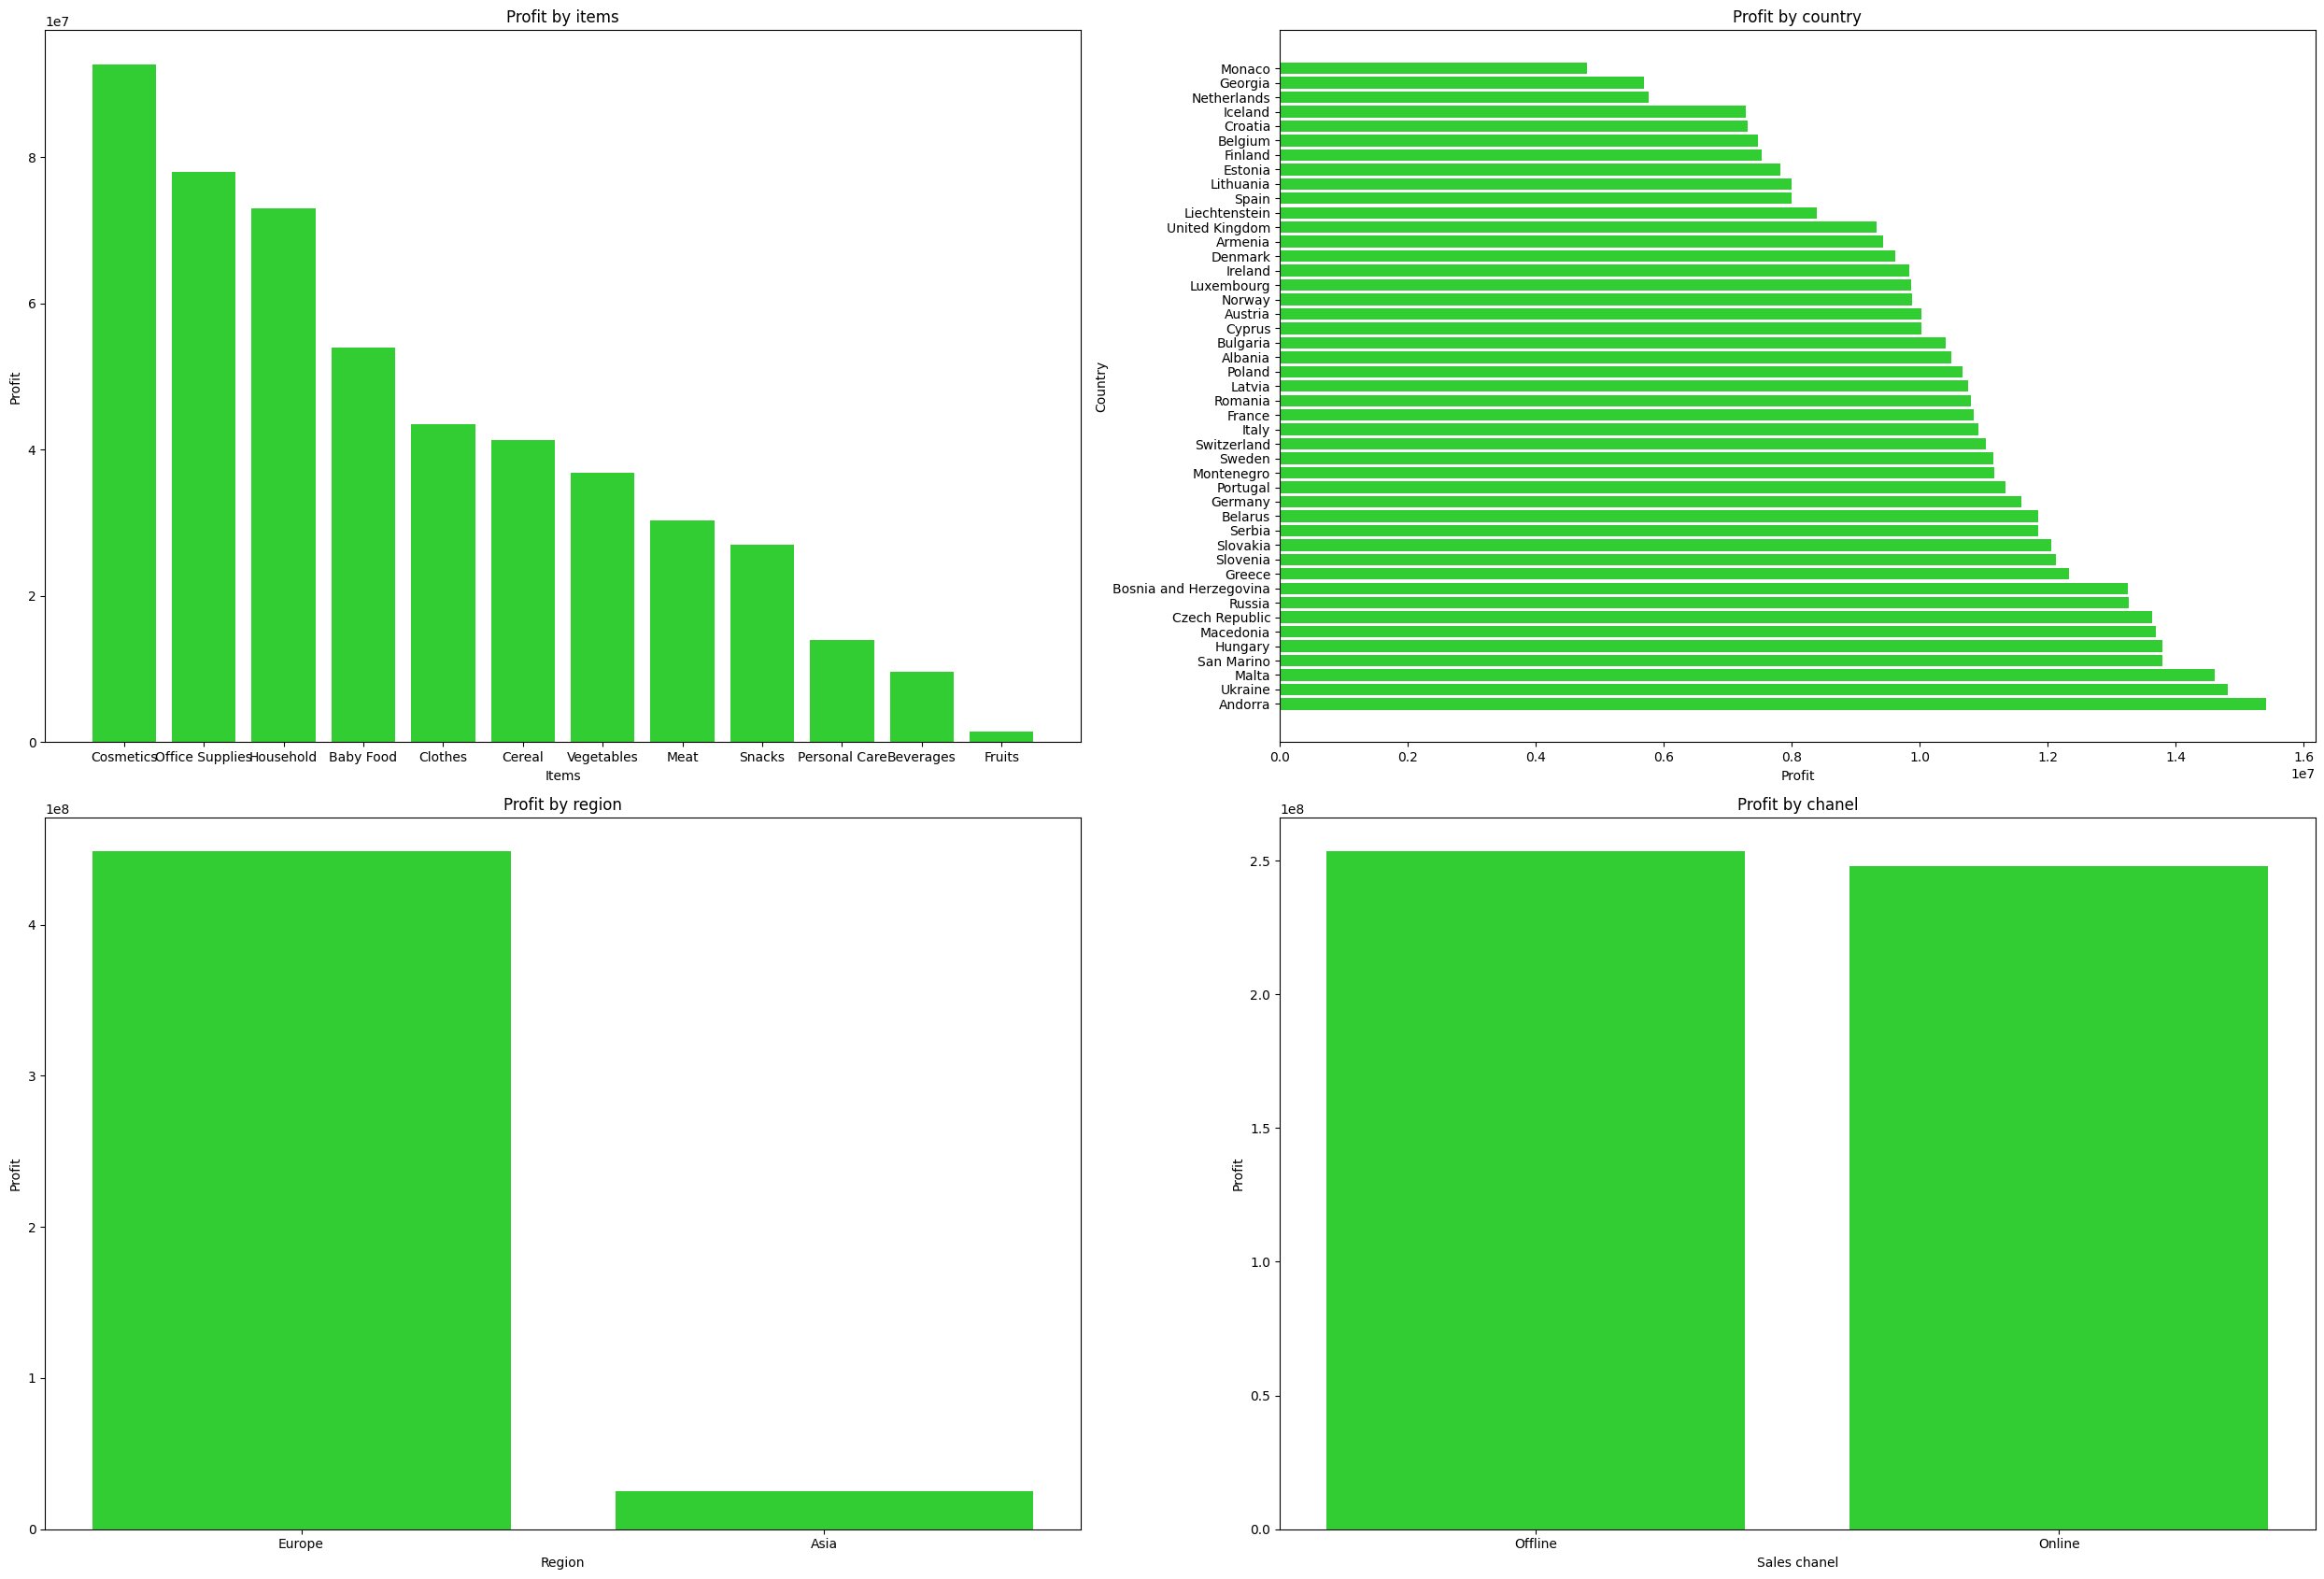

In [ ]:
# прибутки по категоріям товарів; географії (країна, регіон), каналам продажів

profit_by_item = sales_total.groupby("item_type")["profit"].sum().sort_values(ascending = False)
profit_by_country = sales_total.groupby("country")["profit"].sum().sort_values(ascending = False)
profit_by_region = sales_total.groupby("region")["profit"].sum().sort_values(ascending = False)
profit_by_chanel = sales_total.groupby("sales_channel")["profit"].sum().sort_values(ascending = False)


fig, ax = plt.subplots(2, 2, figsize=(25, 17))

ax[0,0].bar(profit_by_item.index, profit_by_item.values, color="limegreen")
ax[0,0].set_title("Profit by items")
ax[0,0].set_xlabel("Items")
ax[0,0].set_ylabel("Profit")

ax[0,1].barh(profit_by_country.index, profit_by_country.values, color="limegreen")
ax[0,1].set_title("Profit by country")
ax[0,1].set_xlabel("Profit")
ax[0,1].set_ylabel("Country")

ax[1,0].bar(profit_by_region.index, profit_by_region.values, color="limegreen")
ax[1,0].set_title("Profit by region")
ax[1,0].set_xlabel("Region")
ax[1,0].set_ylabel("Profit")

ax[1,1].bar(profit_by_chanel.index, profit_by_chanel.values, color="limegreen")
ax[1,1].set_title("Profit by chanel")
ax[1,1].set_xlabel("Sales chanel")
ax[1,1].set_ylabel("Profit")
plt.tight_layout()
plt.show()


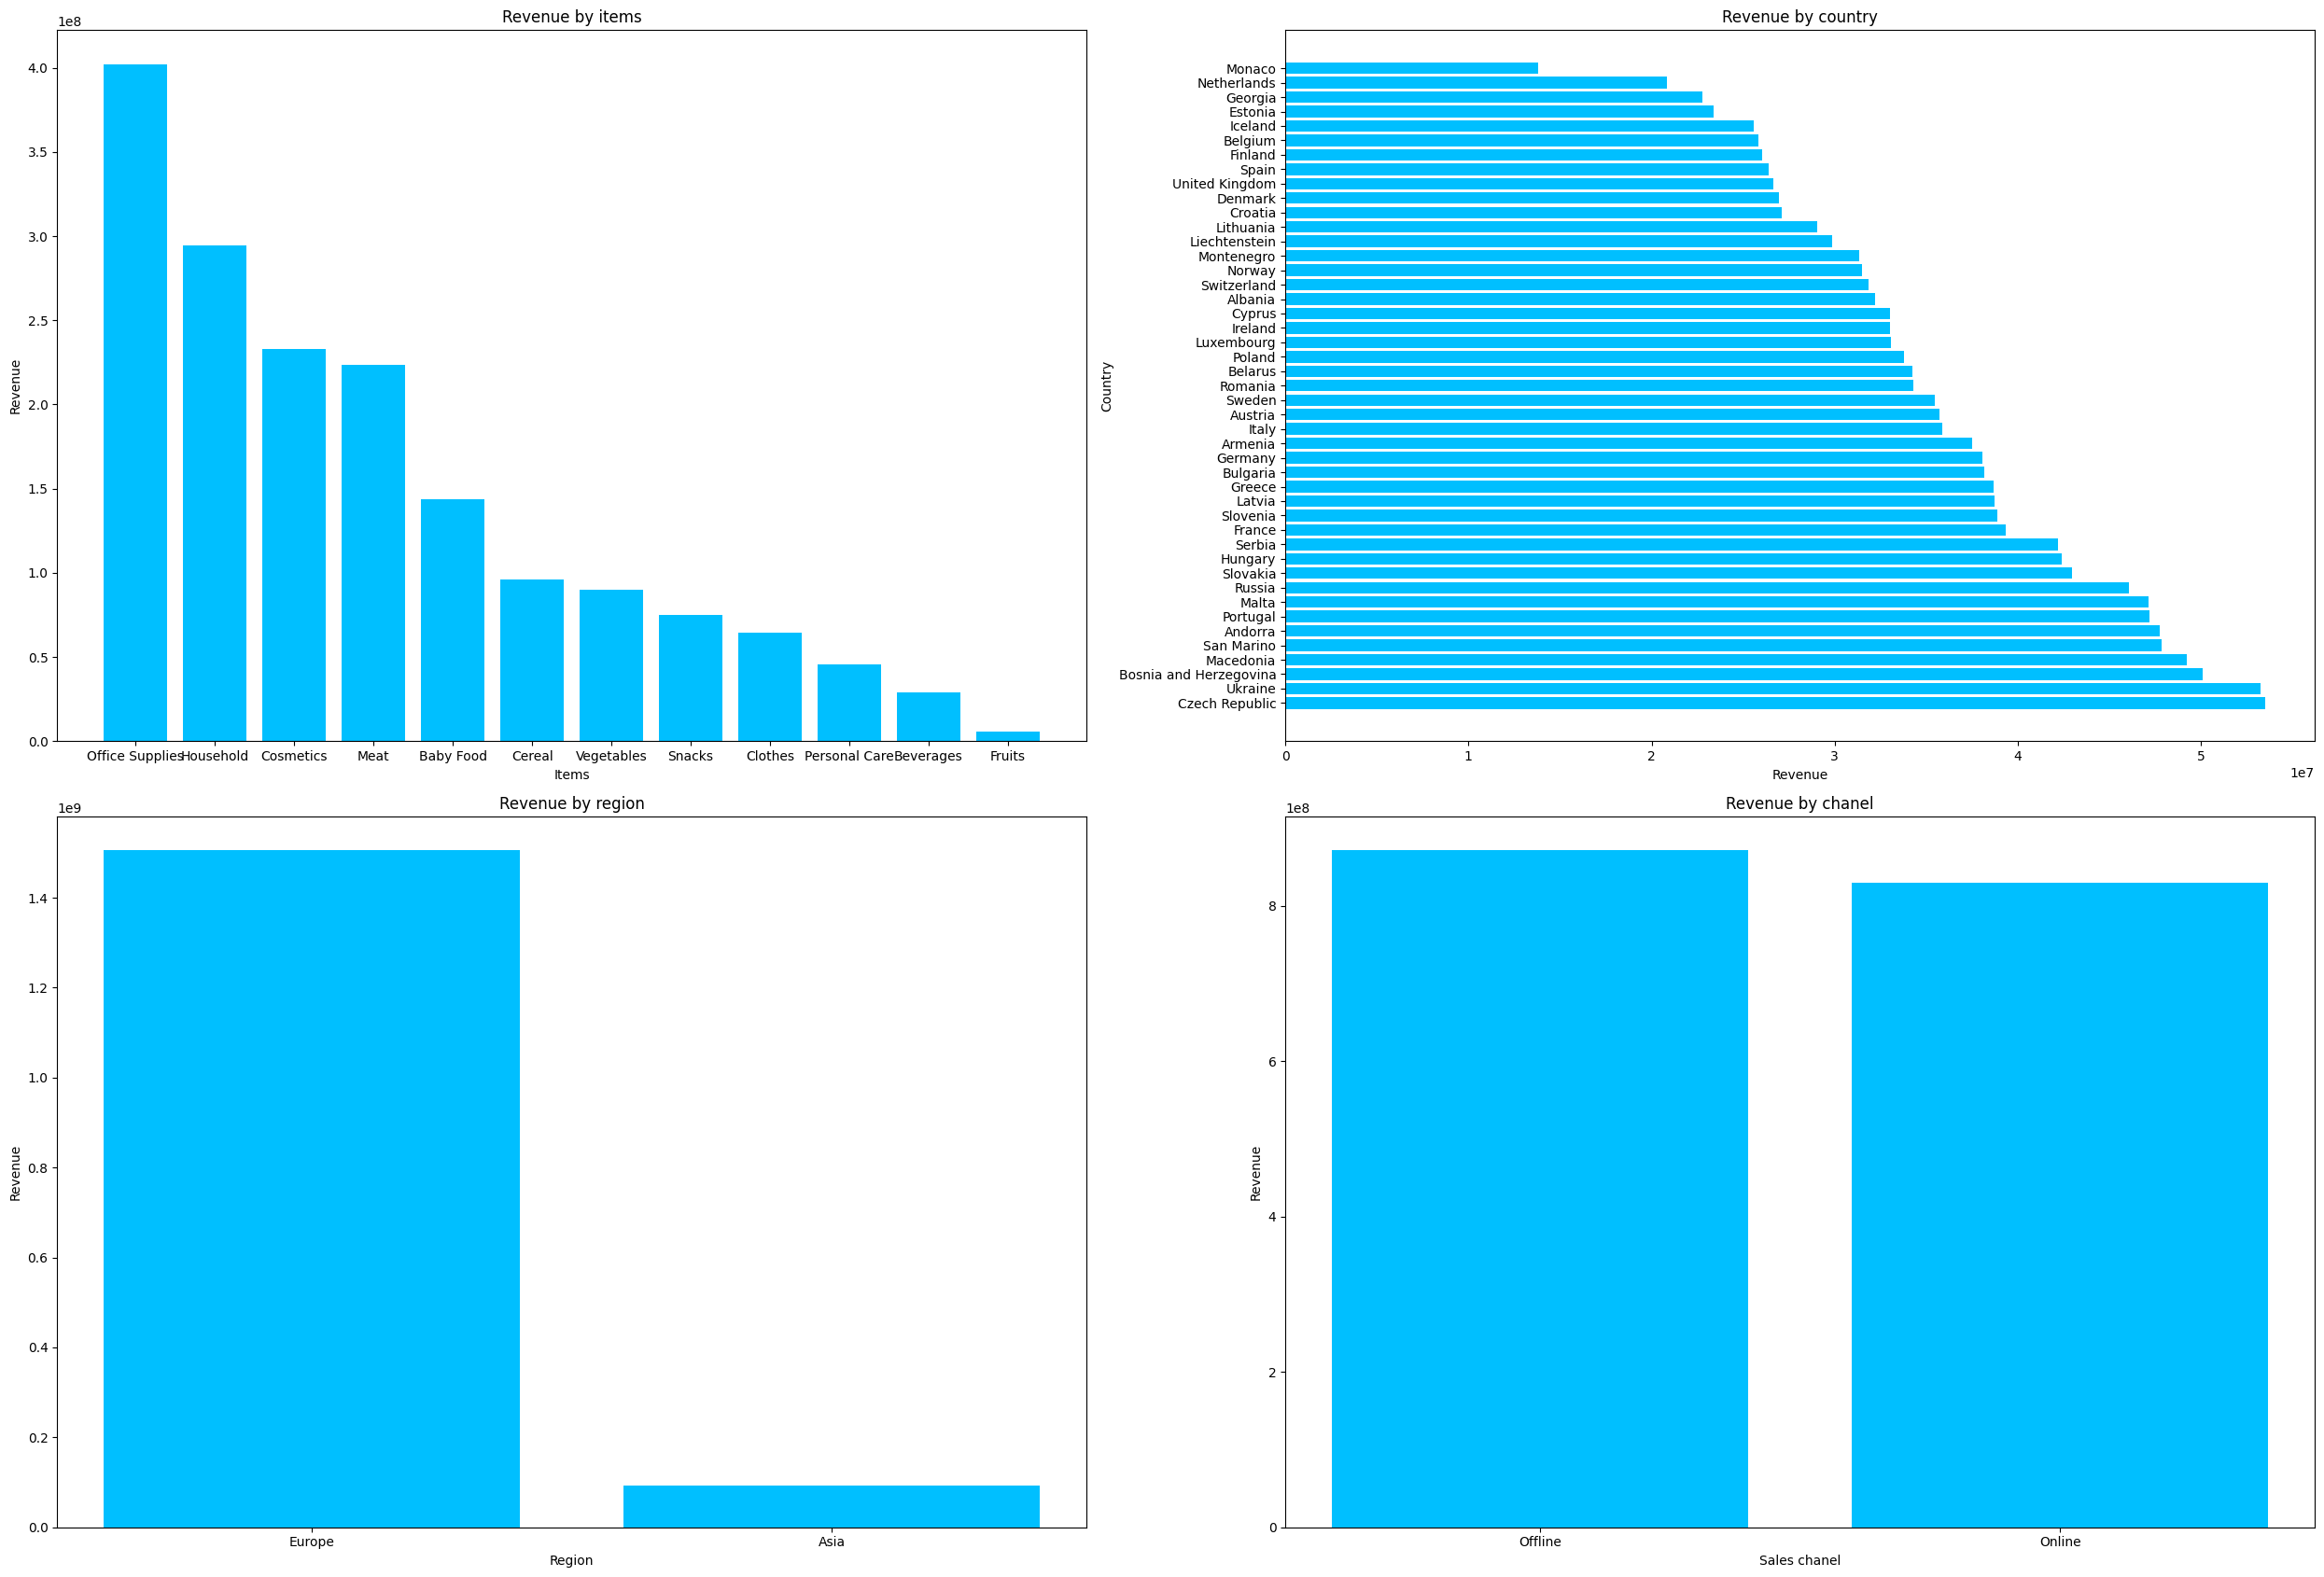

In [ ]:
# дохід по категоріям товарів; географії (країна, регіон), каналам продажів

revenue_by_item = sales_total.groupby("item_type")["revenue"].sum().sort_values(ascending = False)
revenue_by_country = sales_total.groupby("country")["revenue"].sum().sort_values(ascending = False)
revenue_by_region = sales_total.groupby("region")["revenue"].sum().sort_values(ascending = False)
revenue_by_chanel = sales_total.groupby("sales_channel")["revenue"].sum().sort_values(ascending = False)


fig, ax = plt.subplots(2, 2, figsize=(25, 17))

ax[0,0].bar(revenue_by_item.index, revenue_by_item.values, color="deepskyblue")
ax[0,0].set_title("Revenue by items")
ax[0,0].set_xlabel("Items")
ax[0,0].set_ylabel("Revenue")

ax[0,1].barh(revenue_by_country.index, revenue_by_country.values, color="deepskyblue")
ax[0,1].set_title("Revenue by country")
ax[0,1].set_xlabel("Revenue")
ax[0,1].set_ylabel("Country")

ax[1,0].bar(revenue_by_region.index, revenue_by_region.values, color="deepskyblue")
ax[1,0].set_title("Revenue by region")
ax[1,0].set_xlabel("Region")
ax[1,0].set_ylabel("Revenue")

ax[1,1].bar(revenue_by_chanel.index, revenue_by_chanel.values, color="deepskyblue")
ax[1,1].set_title("Revenue by chanel")
ax[1,1].set_xlabel("Sales chanel")
ax[1,1].set_ylabel("Revenue")
plt.tight_layout()
plt.show()

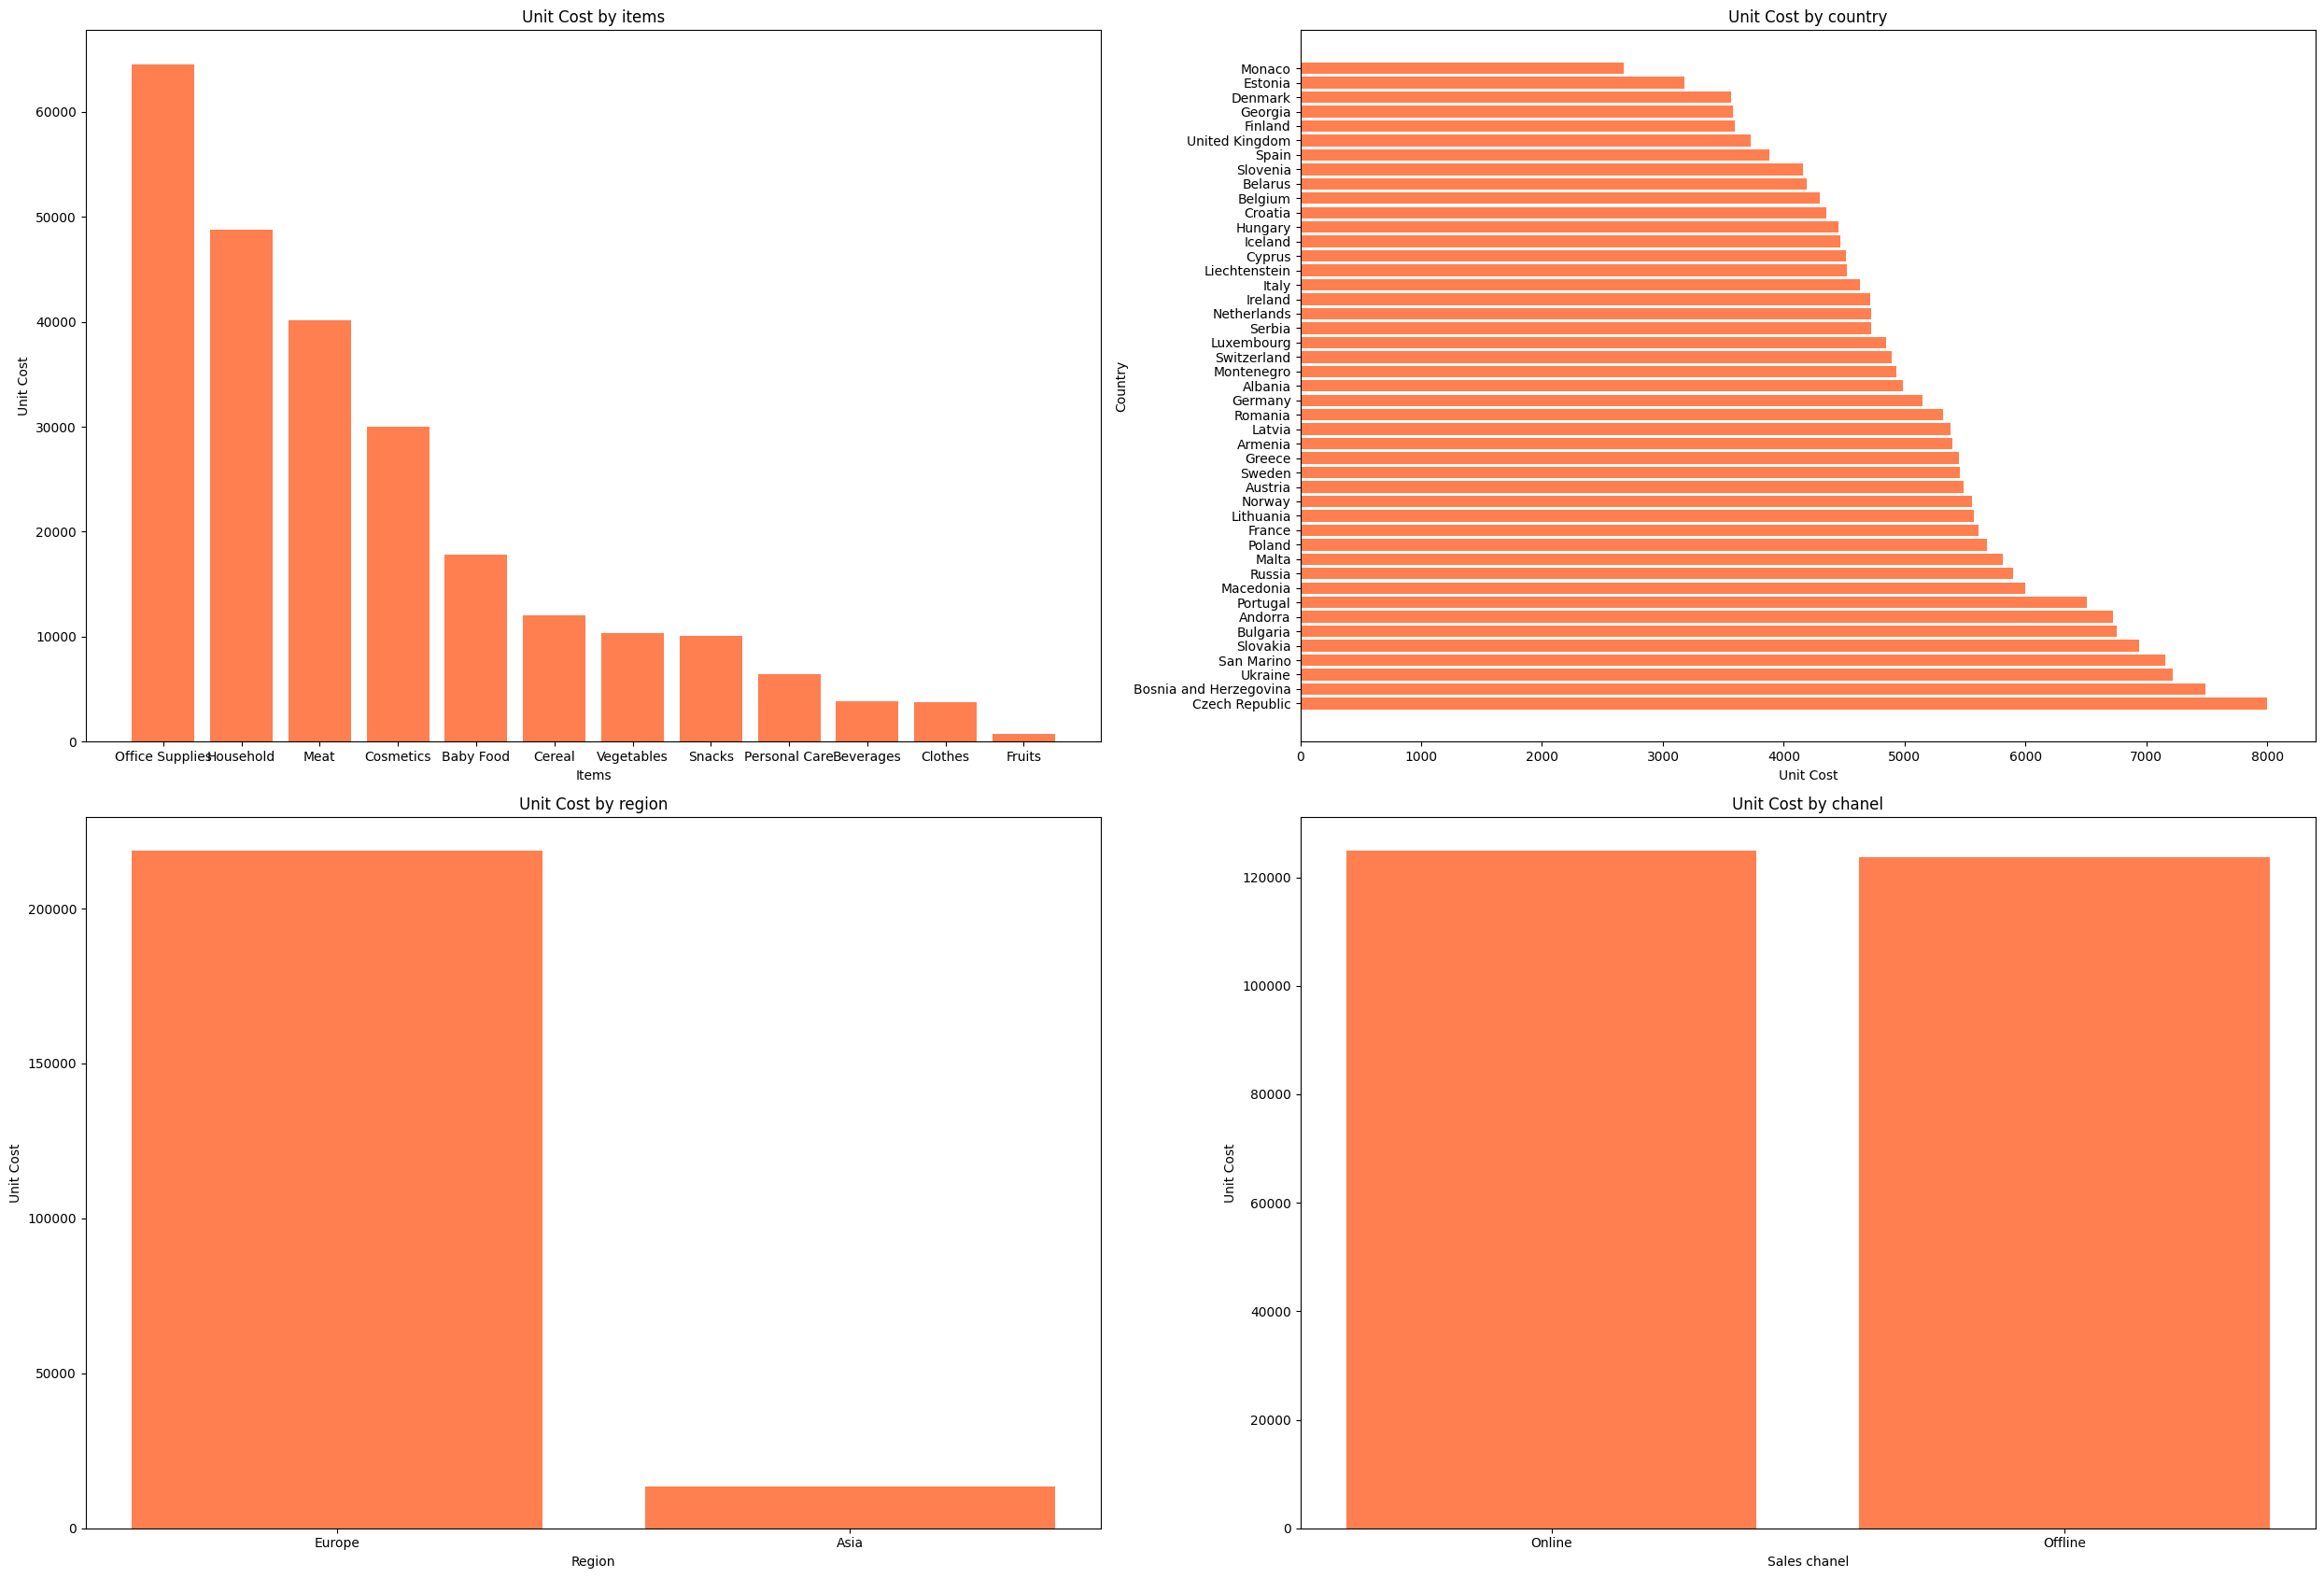

In [ ]:
# витрати по категоріям товарів; географії (країна, регіон), каналам продажів

cost_by_item = sales_total.groupby("item_type")["unit_cost"].sum().sort_values(ascending = False)
cost_by_country = sales_total.groupby("country")["unit_cost"].sum().sort_values(ascending = False)
cost_by_region = sales_total.groupby("region")["unit_cost"].sum().sort_values(ascending = False)
cost_by_chanel = sales_total.groupby("sales_channel")["unit_cost"].sum().sort_values(ascending = False)


fig, ax = plt.subplots(2, 2, figsize=(25, 17))

ax[0,0].bar(cost_by_item.index, cost_by_item.values, color="coral")
ax[0,0].set_title("Unit Cost by items")
ax[0,0].set_xlabel("Items")
ax[0,0].set_ylabel("Unit Cost")

ax[0,1].barh(cost_by_country.index, cost_by_country.values, color="coral")
ax[0,1].set_title("Unit Cost by country")
ax[0,1].set_xlabel("Unit Cost")
ax[0,1].set_ylabel("Country")

ax[1,0].bar(cost_by_region.index, cost_by_region.values, color="coral")
ax[1,0].set_title("Unit Cost by region")
ax[1,0].set_xlabel("Region")
ax[1,0].set_ylabel("Unit Cost")

ax[1,1].bar(cost_by_chanel.index, cost_by_chanel.values, color="coral")
ax[1,1].set_title("Unit Cost by chanel")
ax[1,1].set_xlabel("Sales chanel")
ax[1,1].set_ylabel("Unit Cost")
plt.tight_layout()
plt.show()

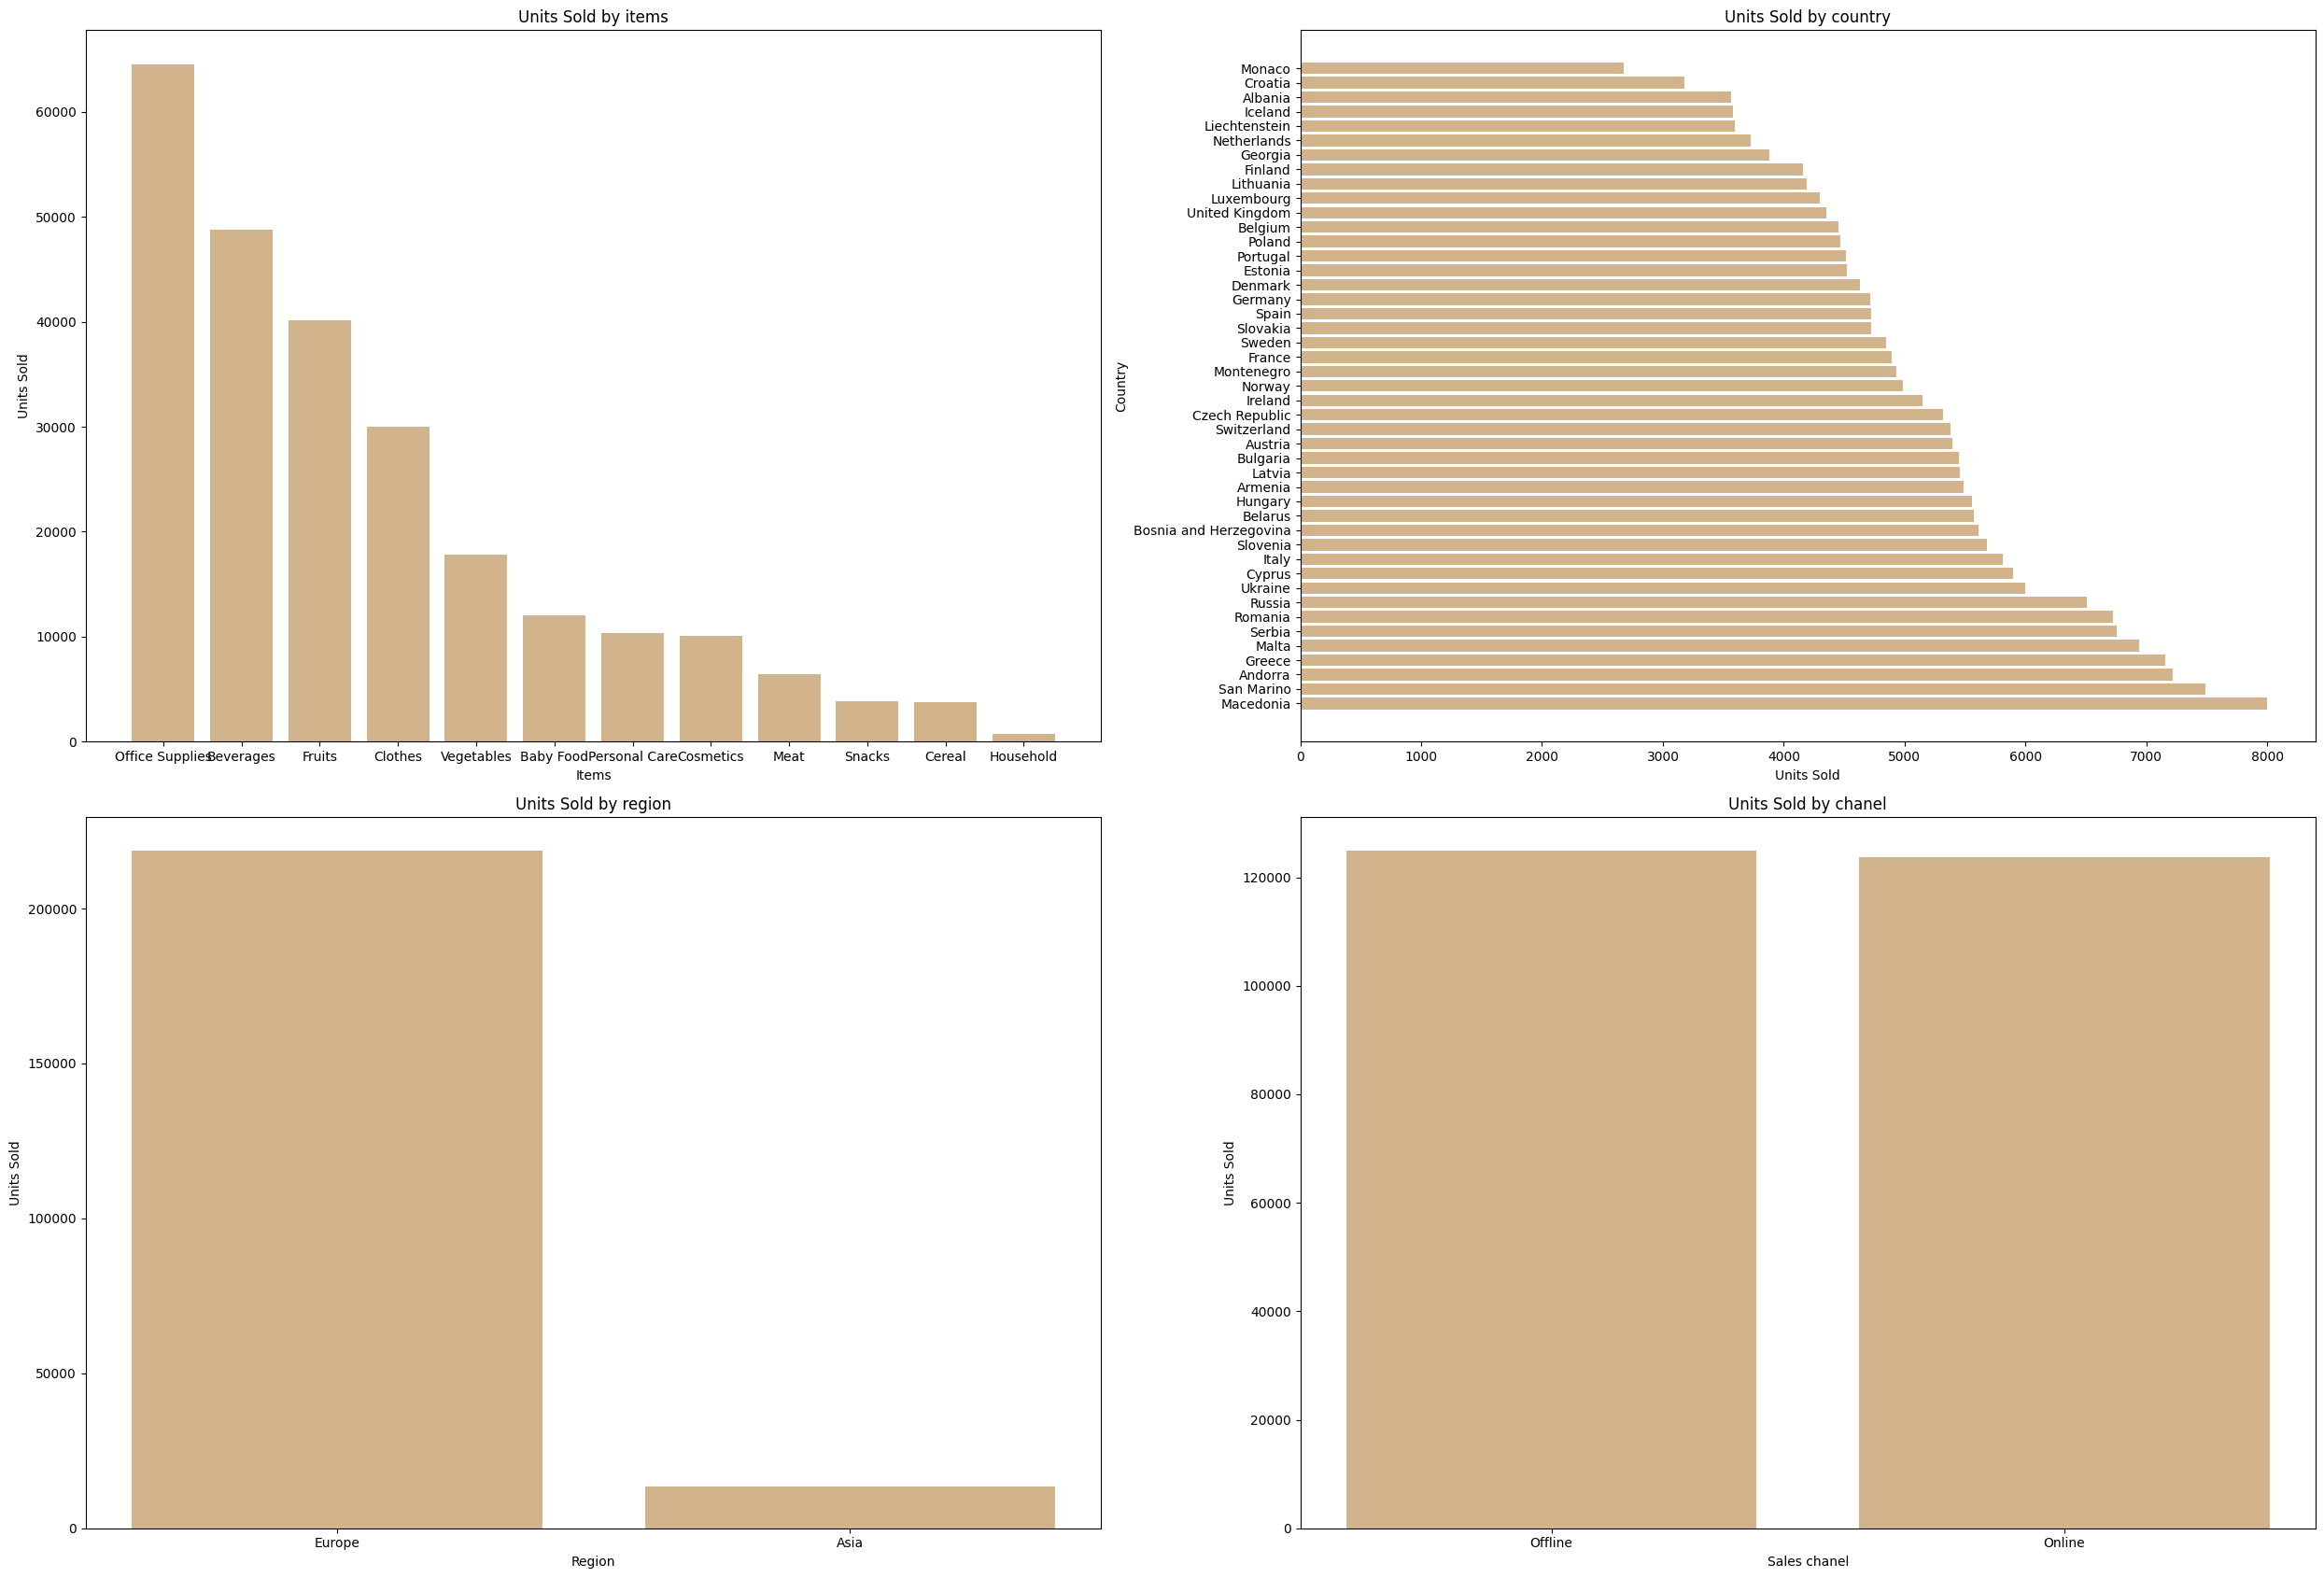

In [ ]:
# популярність по категоріям товарів; географії (країна, регіон), каналам продажів

popular_by_item = sales_total.groupby("item_type")["units_sold"].sum().sort_values(ascending = False)
popular_by_country = sales_total.groupby("country")["units_sold"].sum().sort_values(ascending = False)
popular_by_region = sales_total.groupby("region")["units_sold"].sum().sort_values(ascending = False)
popular_by_chanel = sales_total.groupby("sales_channel")["units_sold"].sum().sort_values(ascending = False)


fig, ax = plt.subplots(2, 2, figsize=(25, 17))

ax[0,0].bar(popular_by_item.index, cost_by_item.values, color="tan")
ax[0,0].set_title("Units Sold by items")
ax[0,0].set_xlabel("Items")
ax[0,0].set_ylabel("Units Sold")

ax[0,1].barh(popular_by_country.index, cost_by_country.values, color="tan")
ax[0,1].set_title("Units Sold by country")
ax[0,1].set_xlabel("Units Sold")
ax[0,1].set_ylabel("Country")

ax[1,0].bar(popular_by_region.index, cost_by_region.values, color="tan")
ax[1,0].set_title("Units Sold by region")
ax[1,0].set_xlabel("Region")
ax[1,0].set_ylabel("Units Sold")

ax[1,1].bar(popular_by_chanel.index, cost_by_chanel.values, color="tan")
ax[1,1].set_title("Units Sold by chanel")
ax[1,1].set_xlabel("Sales chanel")
ax[1,1].set_ylabel("Units Sold")
plt.tight_layout()
plt.show()

## Аналіз впливу різниці інтервал часу між замовленням та його відвантаженням  в розрізі:

*   категорій товарів;
*   країн;
*   регіонів.

## Провдено аналіз на залежність прибутку від часу, необхідного на відвантаження товару.



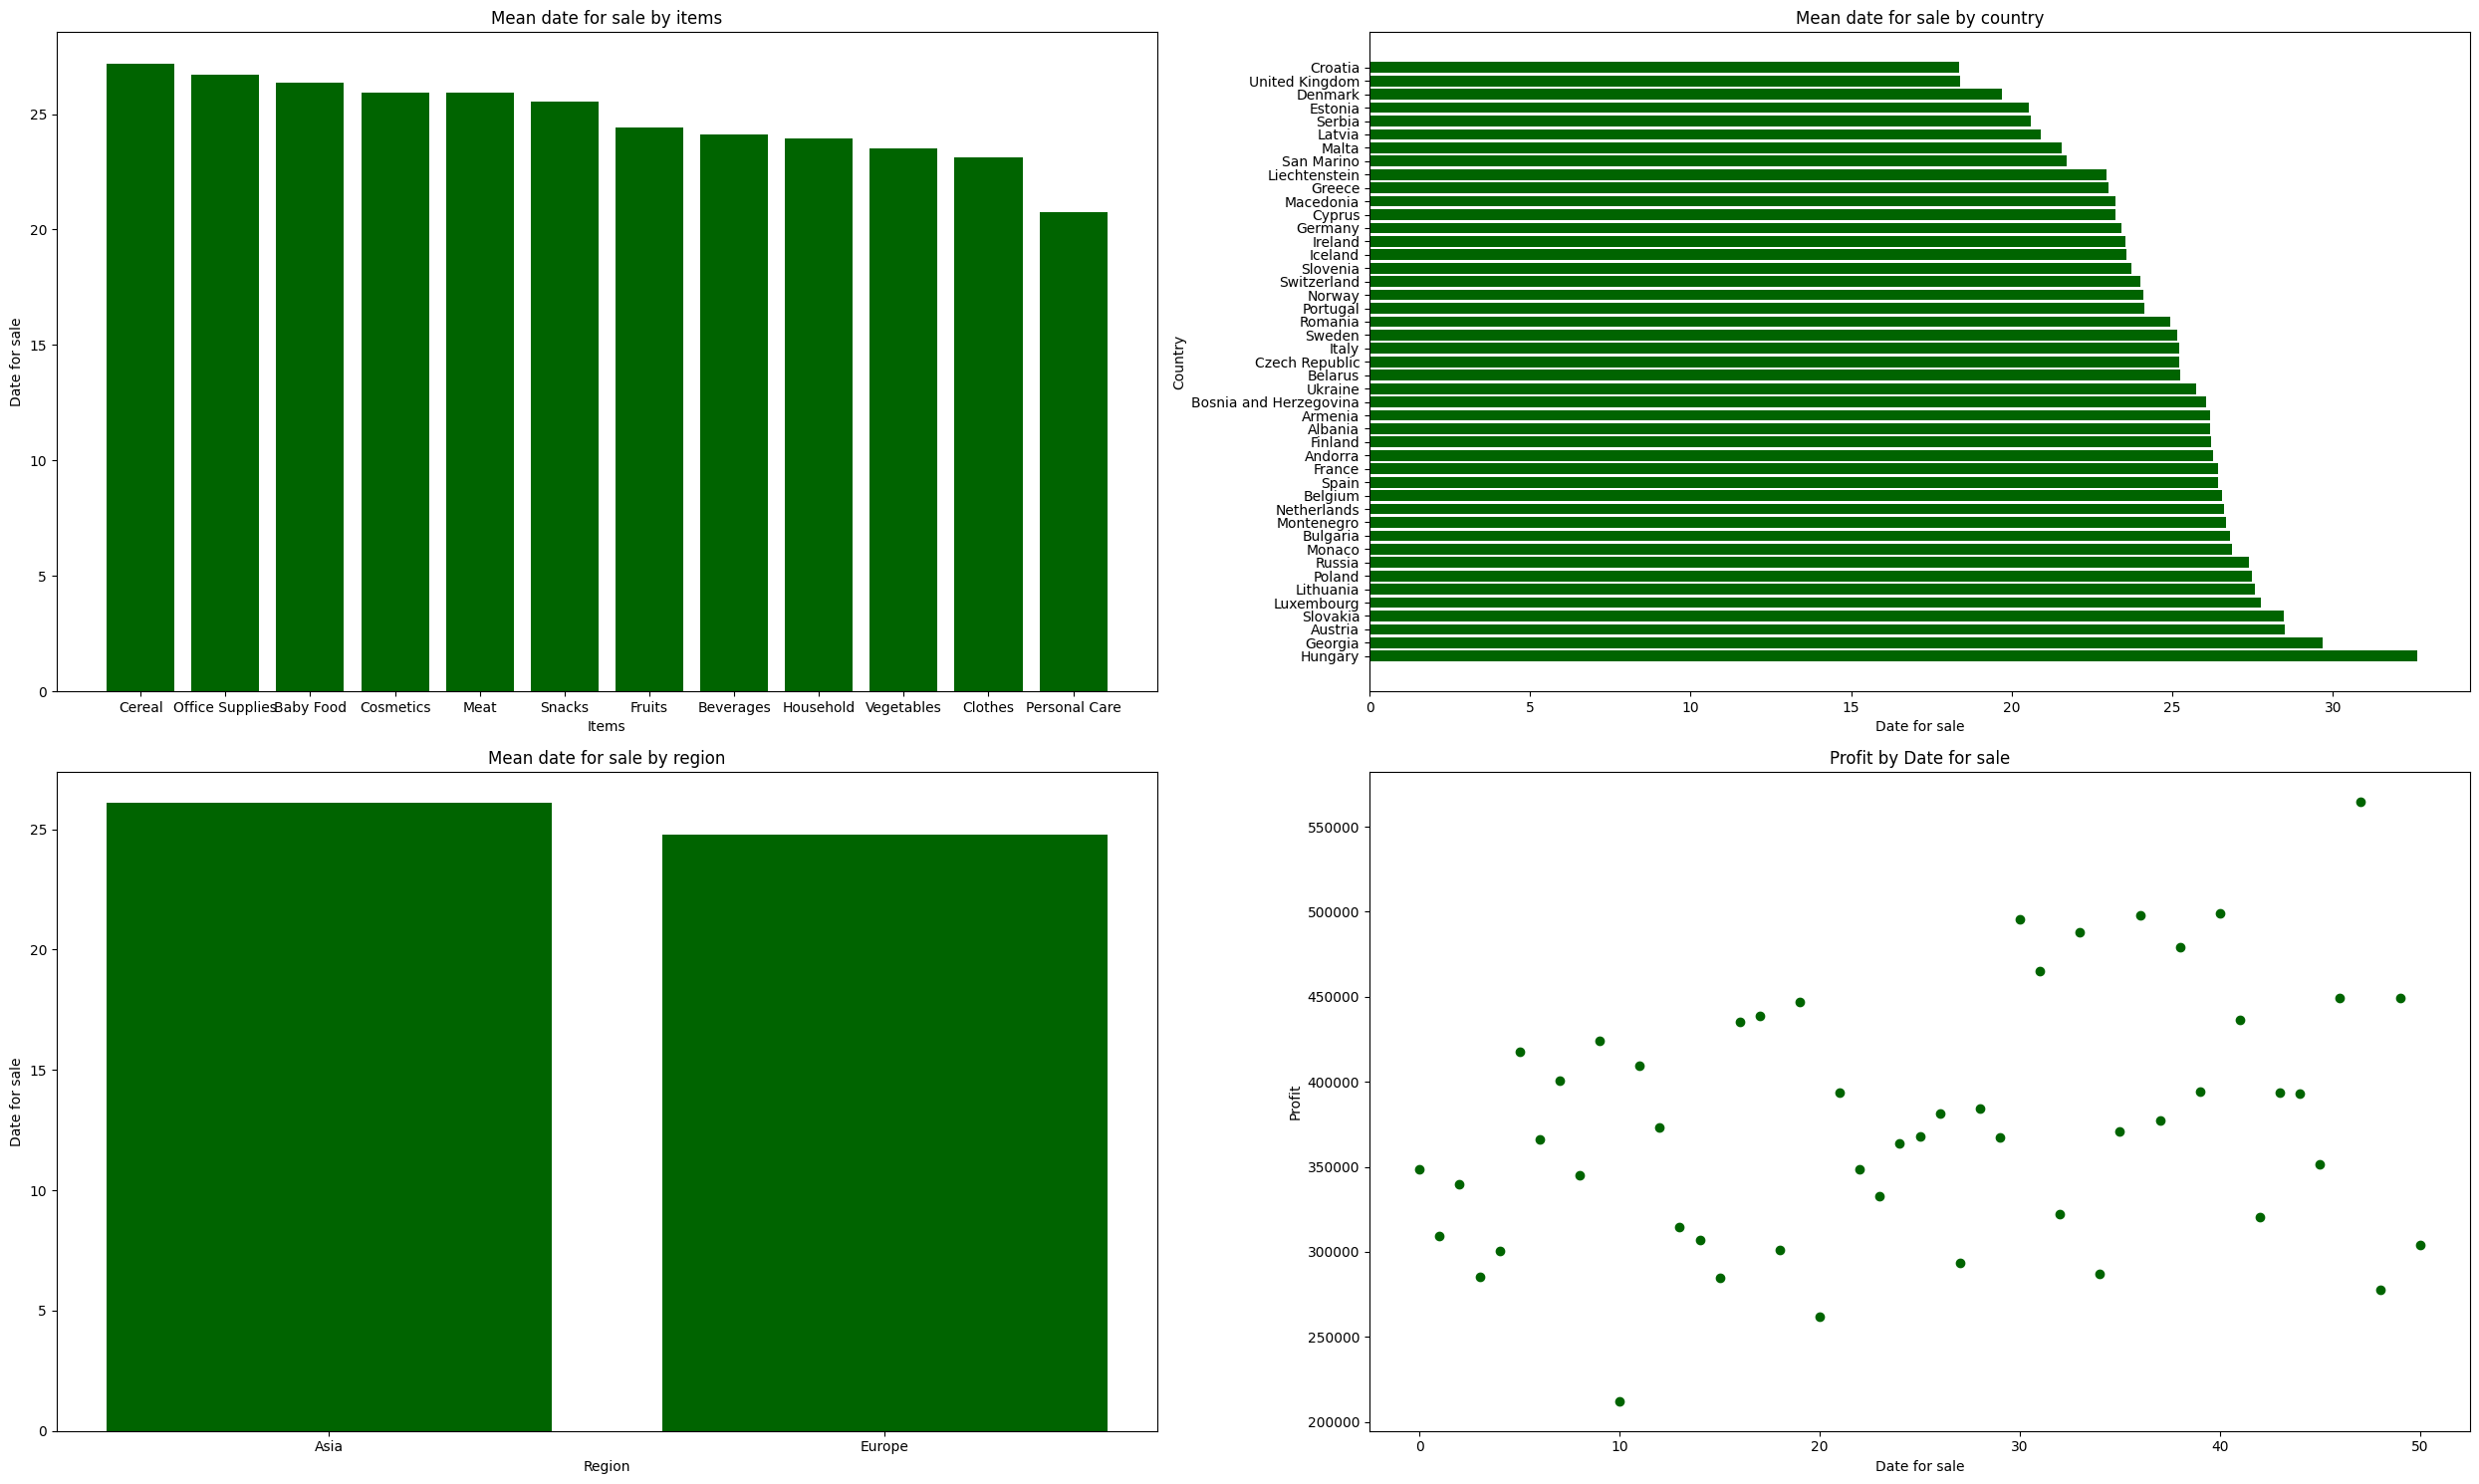

In [ ]:
# plt.hist(sales["difference_date"], bins=100)
date_by_item = sales_total.groupby("item_type")["difference_date"].mean().sort_values(ascending = False)
date_by_country = sales_total.groupby("country")["difference_date"].mean().sort_values(ascending = False)
date_by_region = sales_total.groupby("region")["difference_date"].mean().sort_values(ascending = False)
date_by_profit = sales_total.groupby("difference_date")["profit"].mean()

fig, ax = plt.subplots(2, 2, figsize=(25,15))

ax[0,0].bar(date_by_item.index, date_by_item.values, color="darkgreen")
ax[0,0].set_title("Mean date for sale by items")
ax[0,0].set_xlabel("Items")
ax[0,0].set_ylabel("Date for sale")

ax[0,1].barh(date_by_country.index, date_by_country.values, color="darkgreen")
ax[0,1].set_title("Mean date for sale by country")
ax[0,1].set_xlabel("Date for sale")
ax[0,1].set_ylabel("Country")

ax[1,0].bar(date_by_region.index, date_by_region.values, color="darkgreen")
ax[1,0].set_title("Mean date for sale by region")
ax[1,0].set_xlabel("Region")
ax[1,0].set_ylabel("Date for sale")

ax[1,1].scatter(date_by_profit.index, date_by_profit.values, color="darkgreen")
ax[1,1].set_title("Profit by Date for sale")
ax[1,1].set_xlabel("Date for sale")
ax[1,1].set_ylabel("Profit")
plt.tight_layout()
plt.show()

## Візуалізація динаміки продажів (у часі) у розрізі категорій товарів, країн, регіонів, визнач основні тенденції.

/tmp/ipykernel_546/4247422678.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profit_last_2_years["year_month"] = profit_last_2_years["order_date"].dt.to_period("M")


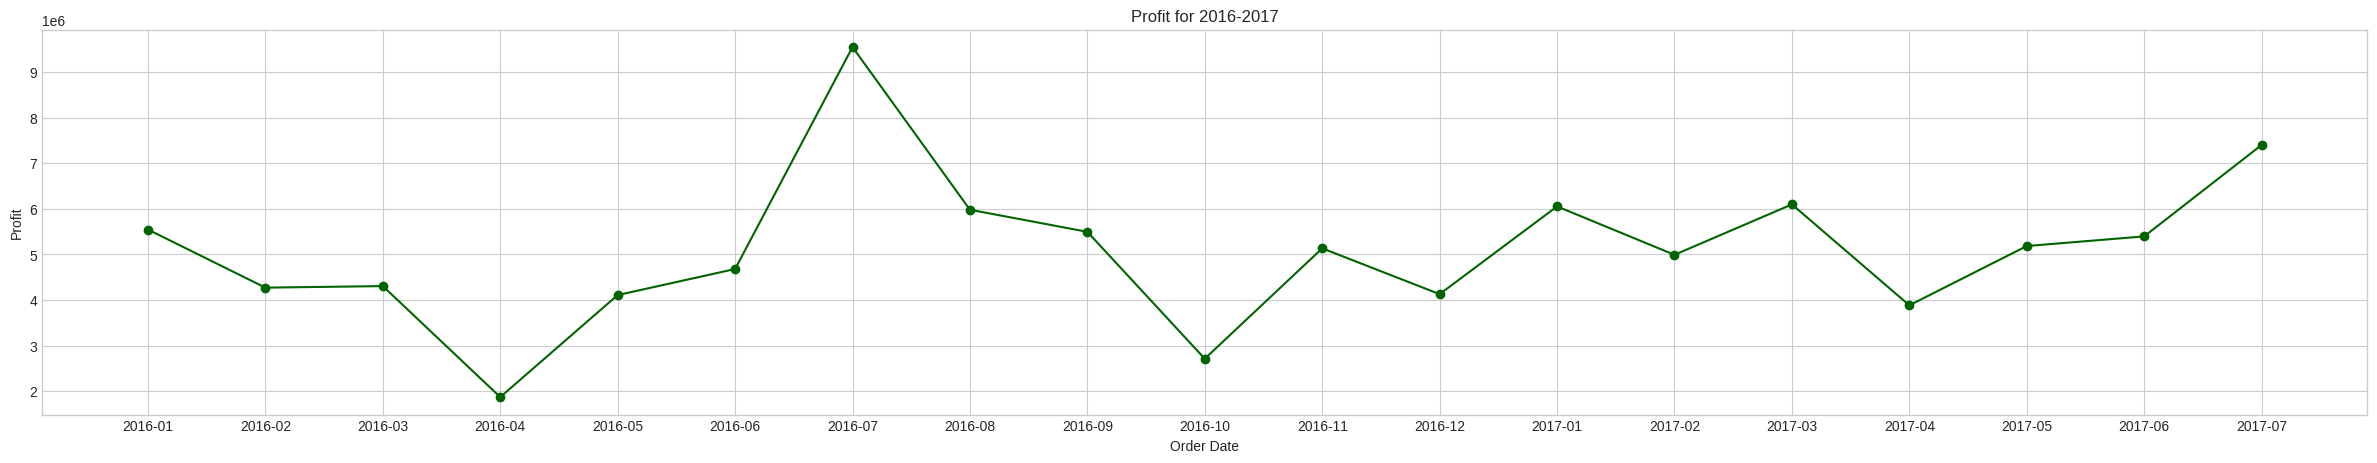

In [ ]:
profit_last_2_years = sales_total[sales_total["order_date"]>"01.01.2016"]
profit_last_2_years["year_month"] = profit_last_2_years["order_date"].dt.to_period("M")
total_profit= profit_last_2_years.groupby("year_month")["profit"].sum().reset_index()

plt.figure(figsize=(30, 5))
plt.style.use("seaborn-v0_8-whitegrid")

plt.plot(total_profit["year_month"].astype(str),total_profit["profit"], marker = "o", color = "darkgreen")
plt.title("Profit for 2016-2017")
plt.xlabel("Order Date")
plt.ylabel("Profit")
plt.show()

/tmp/ipykernel_546/3058767533.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profit_last_2_years["year_month"] = profit_last_2_years["order_date"].dt.to_period("M")


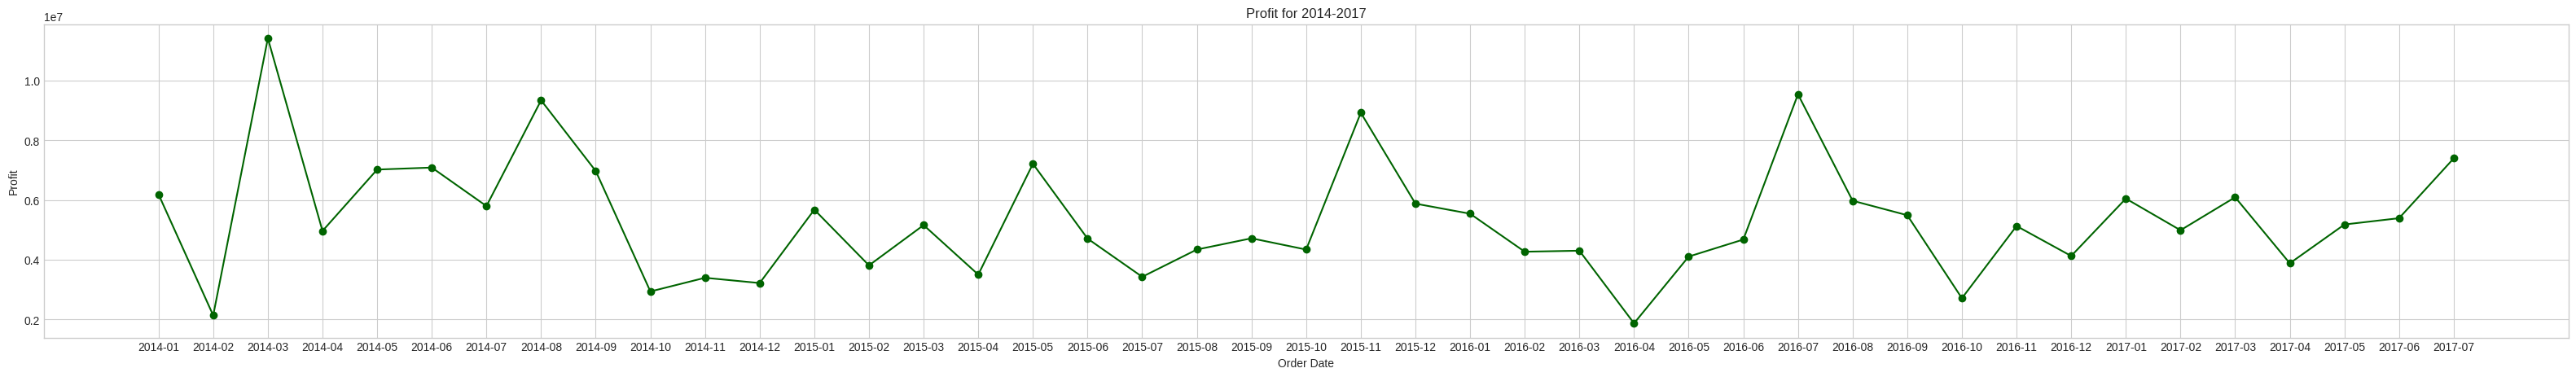

In [ ]:
profit_last_2_years = sales_total[sales_total["order_date"]>"01.01.2014"]
profit_last_2_years["year_month"] = profit_last_2_years["order_date"].dt.to_period("M")
total_profit= profit_last_2_years.groupby("year_month")["profit"].sum().reset_index()

plt.figure(figsize=(40, 5))
plt.style.use("seaborn-v0_8-whitegrid")

plt.plot(total_profit["year_month"].astype(str),total_profit["profit"], marker = "o", color = "darkgreen")
plt.title("Profit for 2014-2017")
plt.xlabel("Order Date")
plt.ylabel("Profit")
plt.show()

In [ ]:
pivot_table_Od_Pr_Ct= pd.pivot_table(
    sales_total,
    values="profit",
    index="order_date",
    columns="country",
    aggfunc="sum",
    fill_value=0
)
pivot_table_Od_Pr_Ct_by_year = pivot_table_Od_Pr_Ct.resample('Y').sum()
pivot_table_Od_Pr_Ct_by_year.head(10)


/tmp/ipykernel_546/4282163376.py:9: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  pivot_table_Od_Pr_Ct_by_year = pivot_table_Od_Pr_Ct.resample('Y').sum()


country,Albania,Andorra,Armenia,Austria,Belarus,Belgium,Bosnia and Herzegovina,Bulgaria,Croatia,Cyprus,...,Russia,San Marino,Serbia,Slovakia,Slovenia,Spain,Sweden,Switzerland,Ukraine,United Kingdom
order_date,,,,,,,,,,,,,,,,,,,,,
2010-12-31,2733094.76,3243222.41,1930234.67,3489734.81,773377.19,470013.36,407978.70,3159778.90,692824.10,432723.11,...,2933514.99,467794.78,771497.78,566207.56,1457975.91,1890557.31,3315255.50,1666975.80,840103.28,957009.89
2011-12-31,1593784.75,677799.93,903658.36,839535.12,1875224.26,770912.38,748347.82,394048.32,19133.58,450242.22,...,2129811.50,699193.28,1980187.03,1025976.10,115946.64,2267788.73,2039984.49,681156.00,3598514.69,657019.62
2012-12-31,1805447.26,3423332.26,1179933.37,210537.95,1872339.31,1012374.70,5708297.00,2422474.88,1959755.71,3015072.06,...,383744.07,3291909.78,1002075.04,3212656.55,1919570.29,834306.78,2219364.70,1787863.14,3732033.07,3166539.27
2013-12-31,108212.64,1205156.65,415253.58,651535.22,1102328.72,654942.94,1274603.57,259786.52,3243433.04,2188047.69,...,1823589.11,1576276.91,3066301.52,1583101.34,1905404.18,657056.76,989680.97,294436.82,113863.86,684764.50
2014-12-31,81133.66,1028468.14,964283.24,1056415.09,904792.84,659139.37,130215.62,1670323.72,364115.52,2319944.20,...,2920495.73,1886580.33,2136539.23,1010312.88,2490814.99,0.00,0.00,3354692.69,2163209.64,0.00
2015-12-31,1406732.31,580266.74,2072917.17,3022172.75,2339000.34,1689715.76,3798679.54,510933.75,0.00,767653.10,...,1613823.06,1720571.49,1509631.35,2325080.33,437122.40,858892.84,97557.86,1260172.13,1314080.69,1961198.23
2016-12-31,2472438.87,4601388.80,1142530.99,485865.15,2270877.27,2070669.26,1189480.52,562063.56,875007.30,278015.38,...,221717.94,2773696.51,215177.43,2318916.09,762777.29,13509.30,976535.80,398613.20,1435583.60,1746844.74
2017-12-31,289861.77,650401.70,813541.80,271713.55,714481.12,148292.37,0.00,1428932.96,163960.20,580522.80,...,1240986.24,1376969.73,1172105.00,10539.18,3033912.82,1480062.30,1516949.27,1593387.82,1607536.91,152935.96


#Розрахуємо чистий прибуток по категоріях товару:

/tmp/ipykernel_546/3473489842.py:4: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  pivot_table_Od_Pr_IT_by_year = pivot_table_Od_Pr_IT.resample('Y').sum()


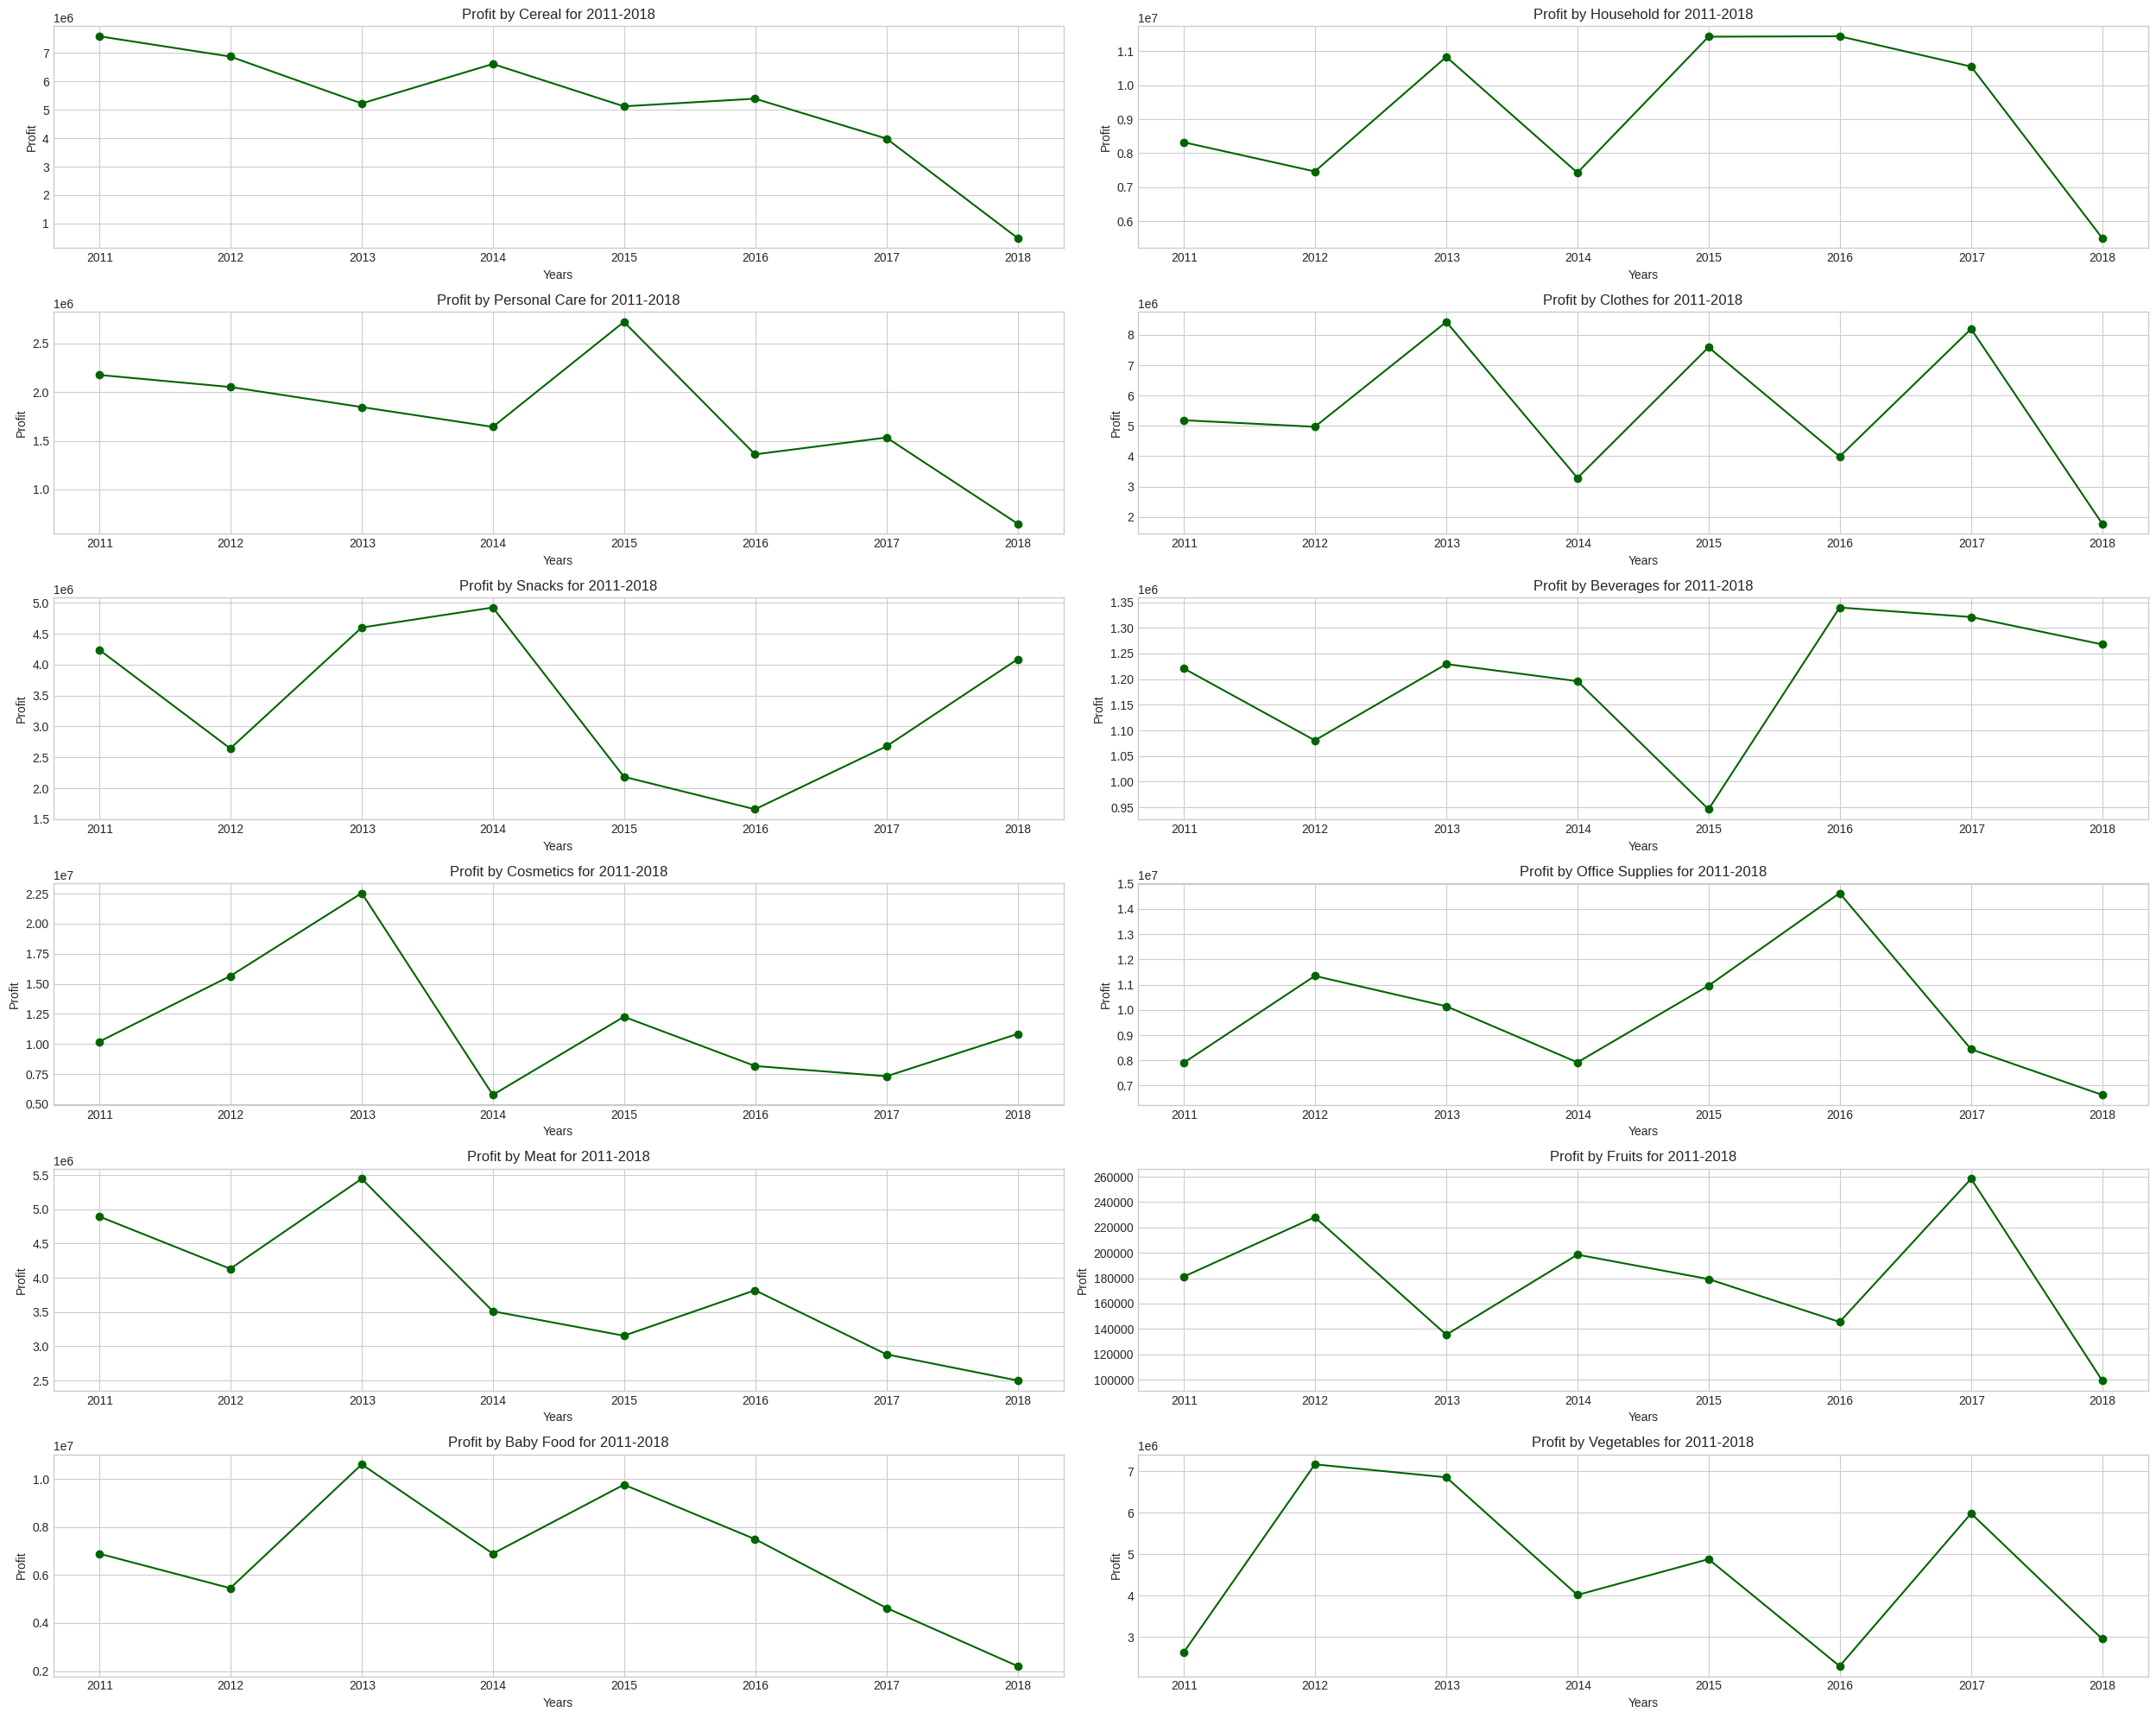

In [ ]:

pivot_table_Od_Pr_IT= pd.pivot_table(
    sales_total, values="profit", index="order_date", columns="item_type", aggfunc="sum", fill_value=0
)
pivot_table_Od_Pr_IT_by_year = pivot_table_Od_Pr_IT.resample('Y').sum()

#Знаходимо всі найменування категорій
sales_total["item_type"].unique()
# array(['Cereal', 'Household', 'Clothes', 'Beverages', 'Office Supplies',
#        'Fruits', 'Vegetables', 'Baby Food', 'Meat', 'Cosmetics', 'Snacks',
#        'Personal Care'], dtype=object)



fig, ax = plt.subplots(6, 2, figsize=(25,20))
# 'Cereal'
Ord_date_by_item=pivot_table_Od_Pr_IT_by_year.groupby("order_date")["Cereal"].sum()
ax[0,0].plot(Ord_date_by_item.index, Ord_date_by_item.values, color="darkgreen", marker = "o")
ax[0,0].set_title("Profit by Cereal for 2011-2018")
ax[0,0].set_xlabel("Years")
ax[0,0].set_ylabel("Profit")

# 'Household'
Ord_date_by_item=pivot_table_Od_Pr_IT_by_year.groupby("order_date")["Household"].sum()
ax[0,1].plot(Ord_date_by_item.index, Ord_date_by_item.values, color="darkgreen", marker = "o")
ax[0,1].set_title("Profit by Household for 2011-2018")
ax[0,1].set_xlabel("Years")
ax[0,1].set_ylabel("Profit")

# 'Clothes'
Ord_date_by_item=pivot_table_Od_Pr_IT_by_year.groupby("order_date")["Clothes"].sum()
ax[1,1].plot(Ord_date_by_item.index, Ord_date_by_item.values, color="darkgreen", marker = "o")
ax[1,1].set_title("Profit by Clothes for 2011-2018")
ax[1,1].set_xlabel("Years")
ax[1,1].set_ylabel("Profit")

# 'Beverages'
Ord_date_by_item=pivot_table_Od_Pr_IT_by_year.groupby("order_date")["Beverages"].sum()
ax[2,1].plot(Ord_date_by_item.index, Ord_date_by_item.values, color="darkgreen", marker = "o")
ax[2,1].set_title("Profit by Beverages for 2011-2018")
ax[2,1].set_xlabel("Years")
ax[2,1].set_ylabel("Profit")

# 'Office Supplies'
Ord_date_by_item=pivot_table_Od_Pr_IT_by_year.groupby("order_date")["Office Supplies"].sum()
ax[3,1].plot(Ord_date_by_item.index, Ord_date_by_item.values, color="darkgreen", marker = "o")
ax[3,1].set_title("Profit by Office Supplies for 2011-2018")
ax[3,1].set_xlabel("Years")
ax[3,1].set_ylabel("Profit")

# 'Fruits'
Ord_date_by_item=pivot_table_Od_Pr_IT_by_year.groupby("order_date")["Fruits"].sum()
ax[4,1].plot(Ord_date_by_item.index, Ord_date_by_item.values, color="darkgreen", marker = "o")
ax[4,1].set_title("Profit by Fruits for 2011-2018")
ax[4,1].set_xlabel("Years")
ax[4,1].set_ylabel("Profit")

# 'Vegetables'
Ord_date_by_item=pivot_table_Od_Pr_IT_by_year.groupby("order_date")["Vegetables"].sum()
ax[5,1].plot(Ord_date_by_item.index, Ord_date_by_item.values, color="darkgreen", marker = "o")
ax[5,1].set_title("Profit by Vegetables for 2011-2018")
ax[5,1].set_xlabel("Years")
ax[5,1].set_ylabel("Profit")

# 'Baby Food'
Ord_date_by_item=pivot_table_Od_Pr_IT_by_year.groupby("order_date")["Baby Food"].sum()
ax[5,0].plot(Ord_date_by_item.index, Ord_date_by_item.values, color="darkgreen", marker = "o")
ax[5,0].set_title("Profit by Baby Food for 2011-2018")
ax[5,0].set_xlabel("Years")
ax[5,0].set_ylabel("Profit")

# 'Meat'
Ord_date_by_item=pivot_table_Od_Pr_IT_by_year.groupby("order_date")["Meat"].sum()
ax[4,0].plot(Ord_date_by_item.index, Ord_date_by_item.values, color="darkgreen", marker = "o")
ax[4,0].set_title("Profit by Meat for 2011-2018")
ax[4,0].set_xlabel("Years")
ax[4,0].set_ylabel("Profit")

# 'Cosmetics'
Ord_date_by_item=pivot_table_Od_Pr_IT_by_year.groupby("order_date")["Cosmetics"].sum()
ax[3,0].plot(Ord_date_by_item.index, Ord_date_by_item.values, color="darkgreen", marker = "o")
ax[3,0].set_title("Profit by Cosmetics for 2011-2018")
ax[3,0].set_xlabel("Years")
ax[3,0].set_ylabel("Profit")

# 'Snacks'
Ord_date_by_item=pivot_table_Od_Pr_IT_by_year.groupby("order_date")["Snacks"].sum()
ax[2,0].plot(Ord_date_by_item.index, Ord_date_by_item.values, color="darkgreen", marker = "o")
ax[2,0].set_title("Profit by Snacks for 2011-2018")
ax[2,0].set_xlabel("Years")
ax[2,0].set_ylabel("Profit")

# 'Personal Care'
Ord_date_by_item=pivot_table_Od_Pr_IT_by_year.groupby("order_date")["Personal Care"].sum()
ax[1,0].plot(Ord_date_by_item.index, Ord_date_by_item.values, color="darkgreen", marker = "o")
ax[1,0].set_title("Profit by Personal Care for 2011-2018")
ax[1,0].set_xlabel("Years")
ax[1,0].set_ylabel("Profit")

plt.tight_layout()
plt.show()

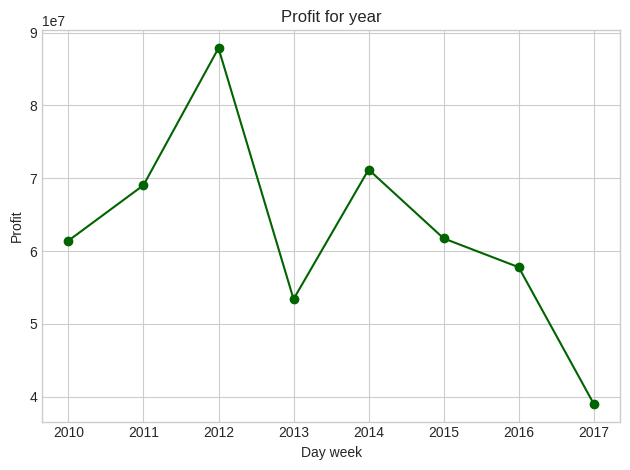

In [ ]:
#Прибуток по рокам
sales_total["year"] =sales_total ["order_date"].dt.to_period("Y")
grp_profit_year =sales_total.groupby("year")["profit"].sum()
grp_profit_year.head()

plt.plot(grp_profit_year.index.astype(str),grp_profit_year.values, marker = "o", color = "darkgreen")
plt.title("Profit for year")
plt.xlabel("Day week")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [ ]:
grp_profit_year.head(10)

,profit
year,
2010,61422459.90
2011,69044659.73
2012,87884066.44
2013,53387995.18
2014,71189625.60
2015,61734039.82
2016,57771920.85
2017,38999691.48


#Розрахуємо чистий прибуток по країнах:

In [ ]:
#Топ-10 країн за прибутком
grp_profit_countries =sales_total.groupby("country")["profit"].sum().sort_values(ascending = False)
grp_profit_countries.head(10)

# Andorra	Ukraine	Malta	San Marino	Hungary	Macedonia	Czech Republic	Russia	Bosnia and Herzegovina	Greece

,profit
country,
Andorra,15410036.63
Ukraine,14804925.74
Malta,14610127.88
San Marino,13792992.81
Hungary,13786231.03
Macedonia,13684099.95
Czech Republic,13635593.78
Russia,13267682.64
Bosnia and Herzegovina,13257602.77


/tmp/ipykernel_546/1200009055.py:4: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  pivot_table_Od_Pr_Cntr_by_year = pivot_table_Od_Pr_Cntr.resample('Y').sum()


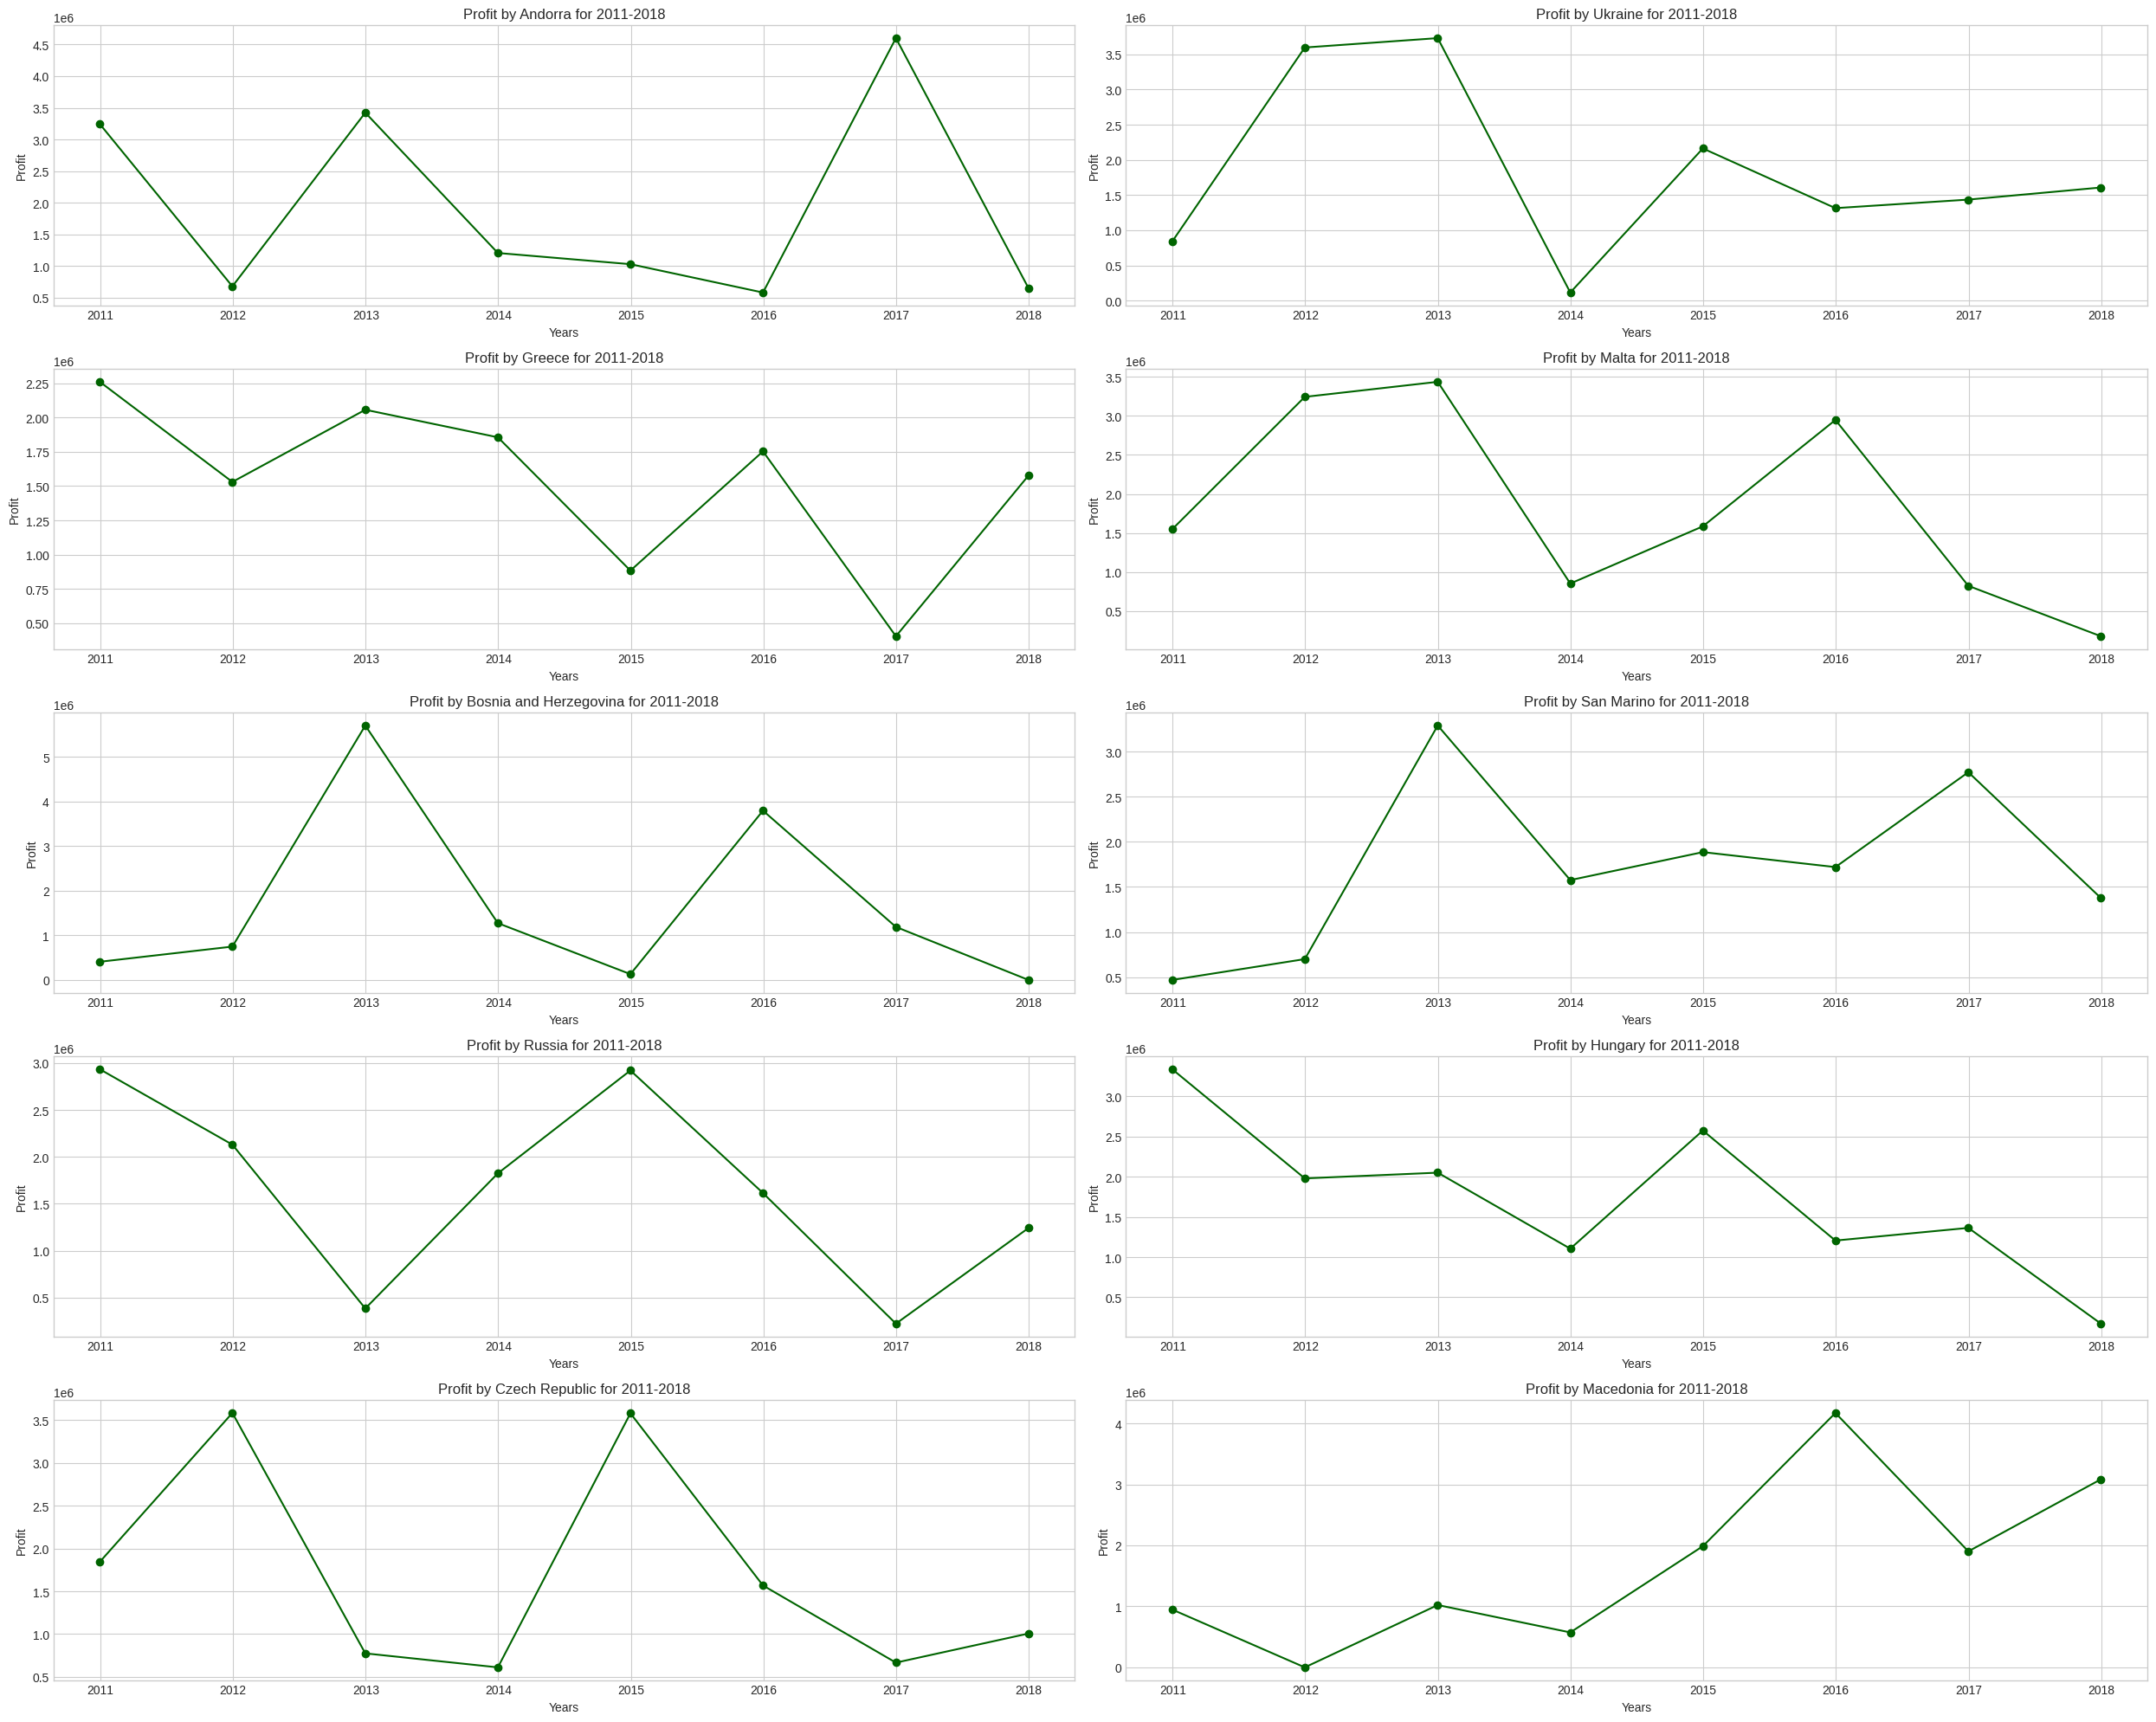

In [ ]:

pivot_table_Od_Pr_Cntr= pd.pivot_table(
    sales_total, values="profit", index="order_date", columns="country", aggfunc="sum", fill_value=0
)
pivot_table_Od_Pr_Cntr_by_year = pivot_table_Od_Pr_Cntr.resample('Y').sum()

fig, ax = plt.subplots(5, 2, figsize=(25,20))

# 'Andorra'
Ord_date_by_country=pivot_table_Od_Pr_Cntr_by_year.groupby("order_date")["Andorra"].sum()
ax[0,0].plot(Ord_date_by_country.index, Ord_date_by_country.values, color="darkgreen", marker = "o")
ax[0,0].set_title("Profit by Andorra for 2011-2018")
ax[0,0].set_xlabel("Years")
ax[0,0].set_ylabel("Profit")

# 'Ukraine'
Ord_date_by_country=pivot_table_Od_Pr_Cntr_by_year.groupby("order_date")["Ukraine"].sum()
ax[0,1].plot(Ord_date_by_country.index, Ord_date_by_country.values, color="darkgreen", marker = "o")
ax[0,1].set_title("Profit by Ukraine for 2011-2018")
ax[0,1].set_xlabel("Years")
ax[0,1].set_ylabel("Profit")

# 'Malta'
Ord_date_by_country=pivot_table_Od_Pr_Cntr_by_year.groupby("order_date")["Malta"].sum()
ax[1,1].plot(Ord_date_by_country.index, Ord_date_by_country.values, color="darkgreen", marker = "o")
ax[1,1].set_title("Profit by Malta for 2011-2018")
ax[1,1].set_xlabel("Years")
ax[1,1].set_ylabel("Profit")

# 'San Marino'
Ord_date_by_country=pivot_table_Od_Pr_Cntr_by_year.groupby("order_date")["San Marino"].sum()
ax[2,1].plot(Ord_date_by_country.index, Ord_date_by_country.values, color="darkgreen", marker = "o")
ax[2,1].set_title("Profit by San Marino for 2011-2018")
ax[2,1].set_xlabel("Years")
ax[2,1].set_ylabel("Profit")

# 'Hungary'
Ord_date_by_country=pivot_table_Od_Pr_Cntr_by_year.groupby("order_date")["Hungary"].sum()
ax[3,1].plot(Ord_date_by_country.index, Ord_date_by_country.values, color="darkgreen", marker = "o")
ax[3,1].set_title("Profit by Hungary for 2011-2018")
ax[3,1].set_xlabel("Years")
ax[3,1].set_ylabel("Profit")

# 'Macedonia'
Ord_date_by_country=pivot_table_Od_Pr_Cntr_by_year.groupby("order_date")["Macedonia"].sum()
ax[4,1].plot(Ord_date_by_country.index, Ord_date_by_country.values, color="darkgreen", marker = "o")
ax[4,1].set_title("Profit by Macedonia for 2011-2018")
ax[4,1].set_xlabel("Years")
ax[4,1].set_ylabel("Profit")

# 'Czech Republic'
Ord_date_by_country=pivot_table_Od_Pr_Cntr_by_year.groupby("order_date")["Czech Republic"].sum()
ax[4,0].plot(Ord_date_by_country.index, Ord_date_by_country.values, color="darkgreen", marker = "o")
ax[4,0].set_title("Profit by Czech Republic for 2011-2018")
ax[4,0].set_xlabel("Years")
ax[4,0].set_ylabel("Profit")

# 'Russia'
Ord_date_by_country=pivot_table_Od_Pr_Cntr_by_year.groupby("order_date")["Russia"].sum()
ax[3,0].plot(Ord_date_by_country.index, Ord_date_by_country.values, color="darkgreen", marker = "o")
ax[3,0].set_title("Profit by Russia for 2011-2018")
ax[3,0].set_xlabel("Years")
ax[3,0].set_ylabel("Profit")

# 'Bosnia and Herzegovina'
Ord_date_by_country=pivot_table_Od_Pr_Cntr_by_year.groupby("order_date")["Bosnia and Herzegovina"].sum()
ax[2,0].plot(Ord_date_by_country.index, Ord_date_by_country.values, color="darkgreen", marker = "o")
ax[2,0].set_title("Profit by Bosnia and Herzegovina for 2011-2018")
ax[2,0].set_xlabel("Years")
ax[2,0].set_ylabel("Profit")

# 'Greece'
Ord_date_by_country=pivot_table_Od_Pr_Cntr_by_year.groupby("order_date")["Greece"].sum()
ax[1,0].plot(Ord_date_by_country.index, Ord_date_by_country.values, color="darkgreen", marker = "o")
ax[1,0].set_title("Profit by Greece for 2011-2018")
ax[1,0].set_xlabel("Years")
ax[1,0].set_ylabel("Profit")

plt.tight_layout()
plt.show()


##Аналіз продажів товарів за днями тижня.

In [ ]:
# Відсортовуємо дати, щоб вони були не числами, а днями тижня
sales_total["order_date"] = pd.to_datetime(sales_total["order_date"])

days = {
    0: "Monday", 1: "Tuesday", 2:"Wednesday", 3:"Thursday",
    4:"Friday", 5: "Saturday", 6:"Sunday"
}
sales_total["day"] = sales_total["order_date"].dt.day_of_week.map(days)
sales_total["day_week"] = pd.Categorical(sales_total["day"], categories= ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"], ordered=True)

sales_total.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,...,profit,revenue,country,region_code,region,sub-region,item_type,year,day,day_week
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,...,57583.50,133705.00,Norway,NO,Europe,Northern Europe,Cereal,2014,Wednesday,Wednesday
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,...,176559.87,409960.10,Serbia,RS,Europe,Southern Europe,Cereal,2016,Thursday,Thursday
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,...,777770.89,3136191.11,NaN,NaN,NaN,NaN,Household,2014,Friday,Friday
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,...,85998.24,127966.88,Montenegro,ME,Europe,Southern Europe,Clothes,2017,Saturday,Saturday
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,...,119767.68,362897.60,Serbia,RS,Europe,Southern Europe,Beverages,2012,Saturday,Saturday


##Аналіз продажів товарів за місяцями.

/tmp/ipykernel_546/875446851.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Orderdate_by_month = sales_total.groupby("day_week")["profit"].sum()


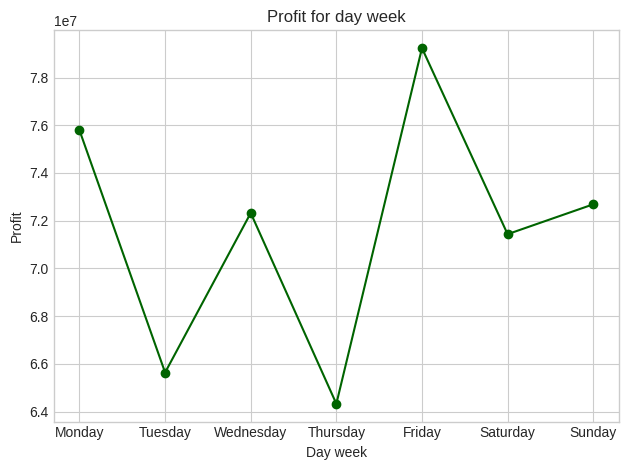

In [ ]:


Orderdate_by_month = sales_total.groupby("day_week")["profit"].sum()

plt.plot(Orderdate_by_month.index,Orderdate_by_month.values, marker = "o", color = "darkgreen")
plt.title("Profit for day week")
plt.xlabel("Day week")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

/tmp/ipykernel_546/2393756355.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table_Mth_Pr_IT= pd.pivot_table(
/tmp/ipykernel_546/2393756355.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Day_by_item=pivot_table_Mth_Pr_IT.groupby("day_week")["Cereal"].sum()
/tmp/ipykernel_546/2393756355.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Day_by_item=pivot_table_Mth_Pr_IT.groupby("day_week")["Household"].sum()
/tmp/ipykernel_546/239

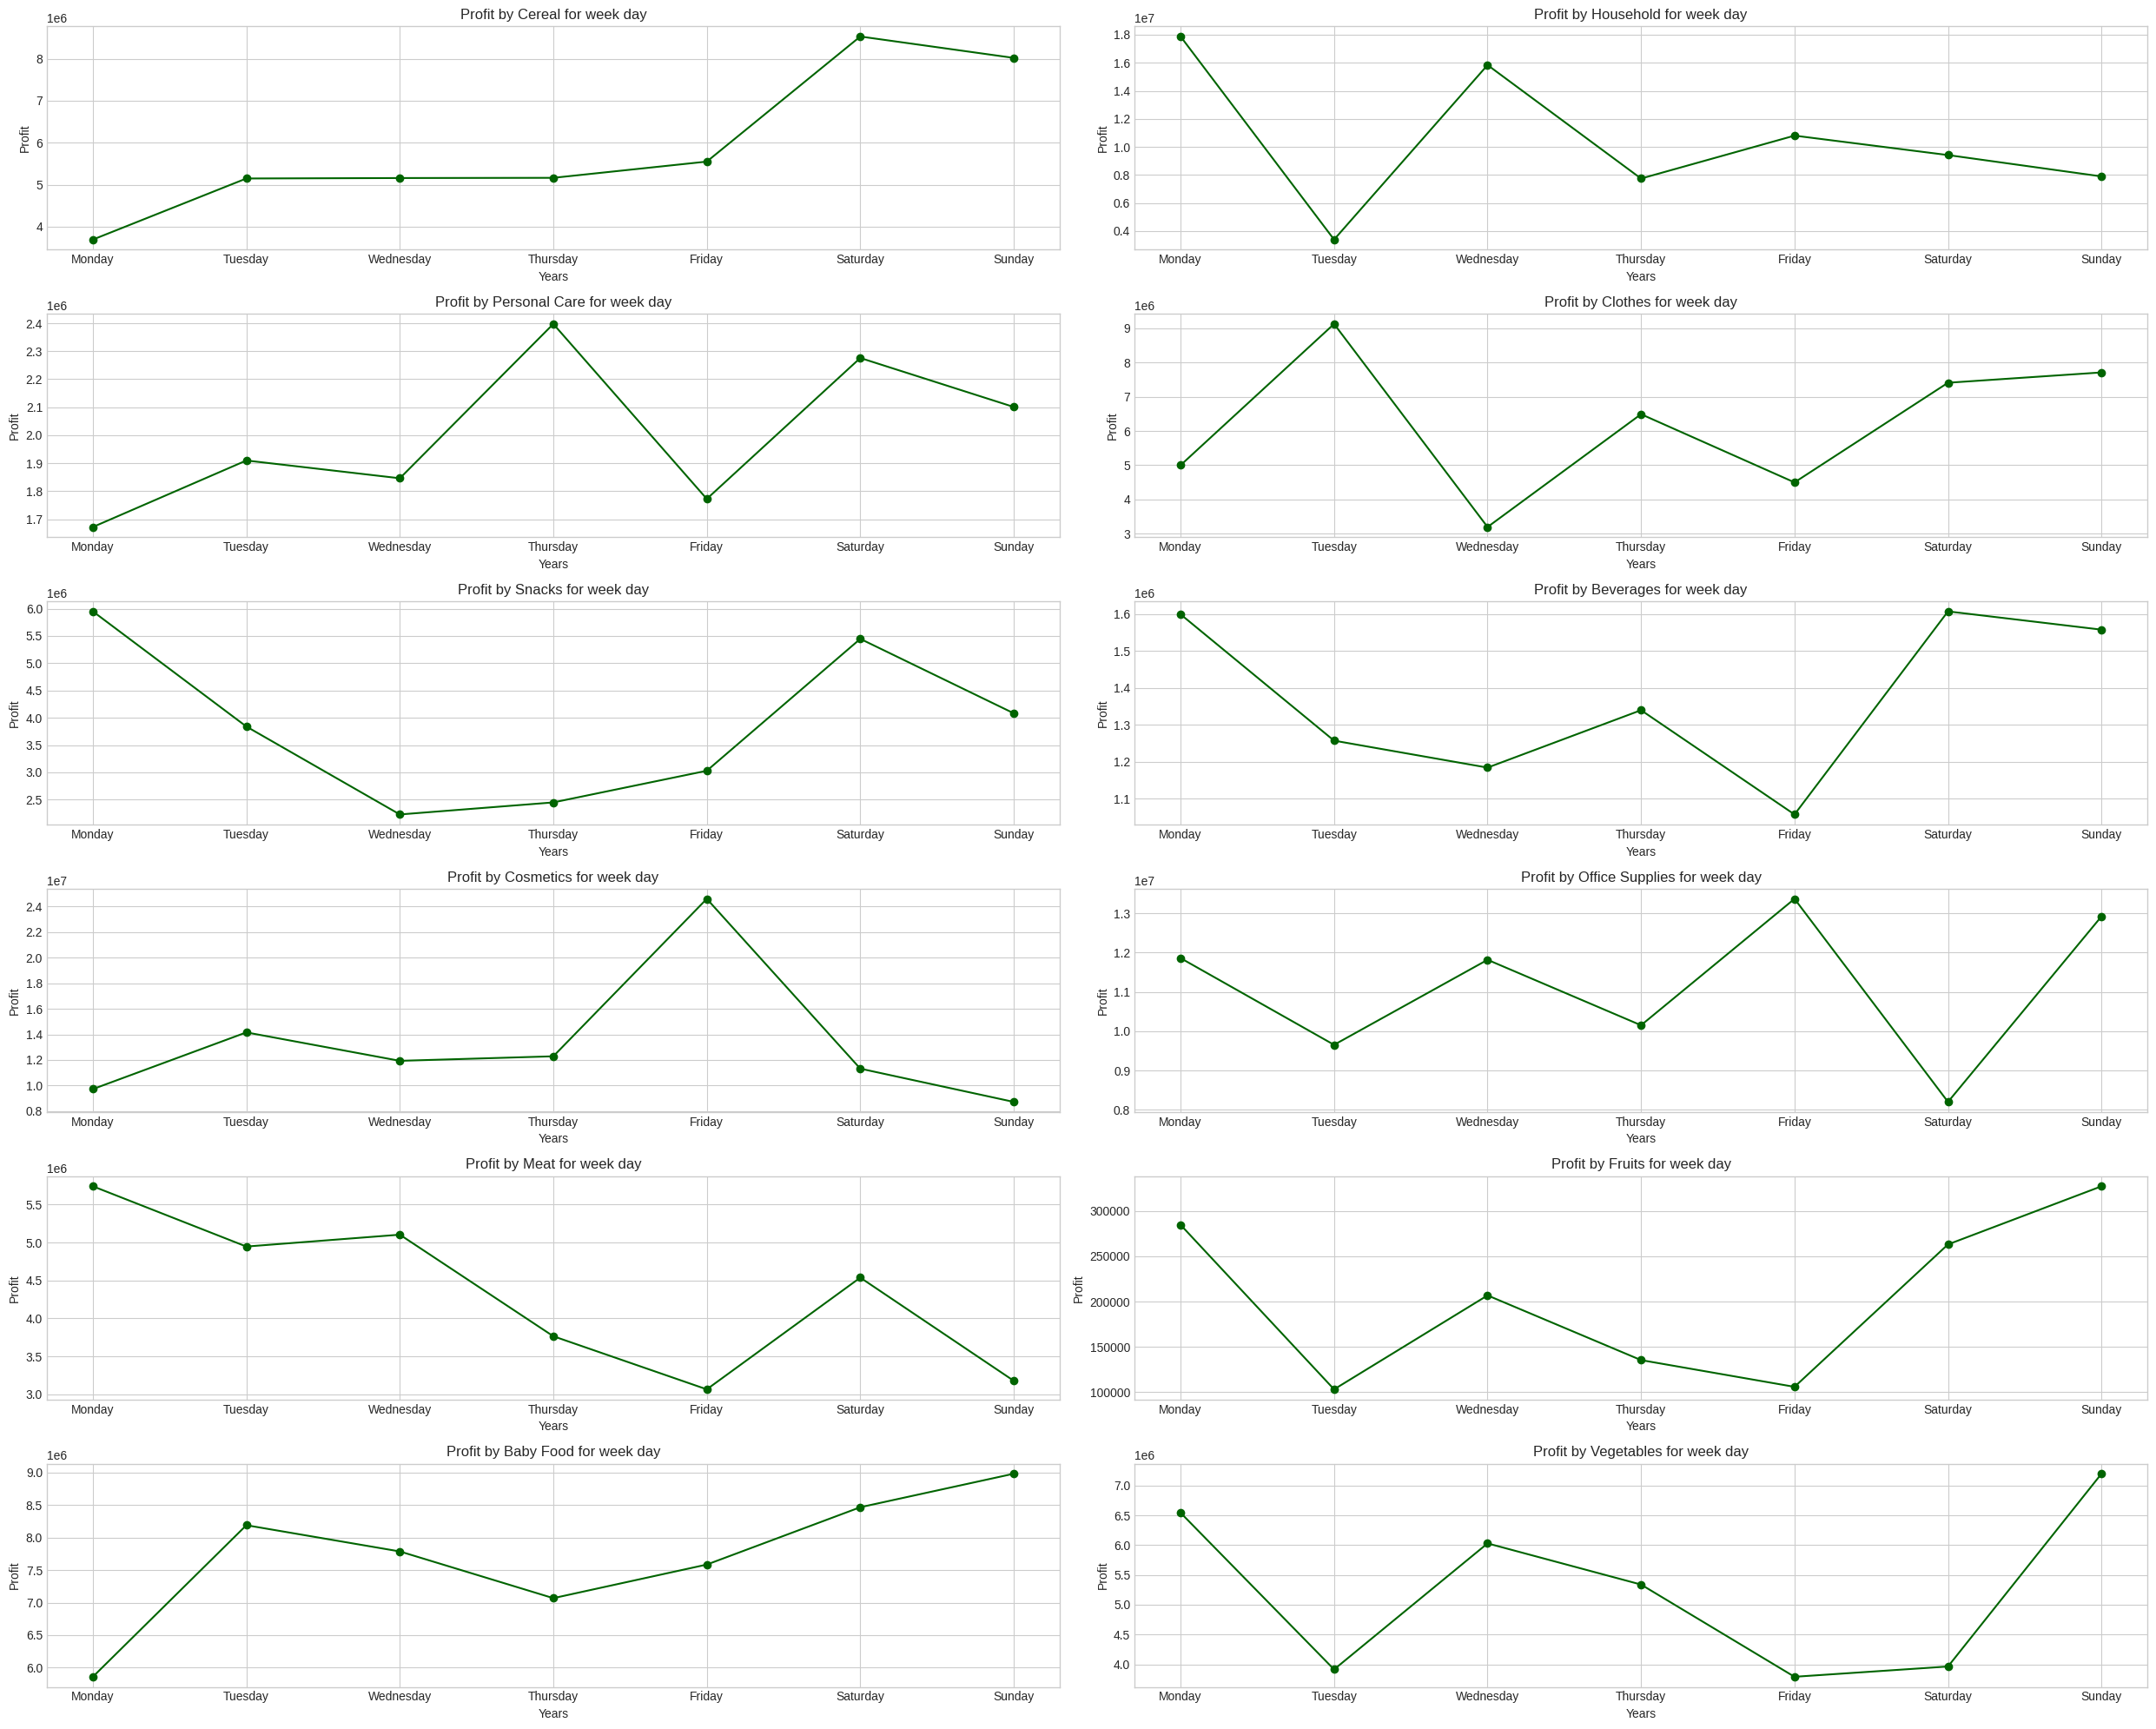

In [ ]:
pivot_table_Mth_Pr_IT= pd.pivot_table(
    sales_total, values="profit", index="day_week", columns="item_type", aggfunc="sum", fill_value=0
)

#Знаходимо всі найменування категорій
sales_total["item_type"].unique()
# array(['Cereal', 'Household', 'Clothes', 'Beverages', 'Office Supplies',
#        'Fruits', 'Vegetables', 'Baby Food', 'Meat', 'Cosmetics', 'Snacks',
#        'Personal Care'], dtype=object)



fig, ax = plt.subplots(6, 2, figsize=(25,20))
# 'Cereal'
Day_by_item=pivot_table_Mth_Pr_IT.groupby("day_week")["Cereal"].sum()
ax[0,0].plot(Day_by_item.index, Day_by_item.values, color="darkgreen", marker = "o")
ax[0,0].set_title("Profit by Cereal for week day")
ax[0,0].set_xlabel("Years")
ax[0,0].set_ylabel("Profit")

# 'Household'
Day_by_item=pivot_table_Mth_Pr_IT.groupby("day_week")["Household"].sum()
ax[0,1].plot(Day_by_item.index, Day_by_item.values, color="darkgreen", marker = "o")
ax[0,1].set_title("Profit by Household for week day")
ax[0,1].set_xlabel("Years")
ax[0,1].set_ylabel("Profit")

# 'Clothes'
Day_by_item=pivot_table_Mth_Pr_IT.groupby("day_week")["Clothes"].sum()
ax[1,1].plot(Day_by_item.index, Day_by_item.values, color="darkgreen", marker = "o")
ax[1,1].set_title("Profit by Clothes for week day")
ax[1,1].set_xlabel("Years")
ax[1,1].set_ylabel("Profit")

# 'Beverages'
Day_by_item=pivot_table_Mth_Pr_IT.groupby("day_week")["Beverages"].sum()
ax[2,1].plot(Day_by_item.index, Day_by_item.values, color="darkgreen", marker = "o")
ax[2,1].set_title("Profit by Beverages for week day")
ax[2,1].set_xlabel("Years")
ax[2,1].set_ylabel("Profit")

# 'Office Supplies'
Day_by_item=pivot_table_Mth_Pr_IT.groupby("day_week")["Office Supplies"].sum()
ax[3,1].plot(Day_by_item.index, Day_by_item.values, color="darkgreen", marker = "o")
ax[3,1].set_title("Profit by Office Supplies for week day")
ax[3,1].set_xlabel("Years")
ax[3,1].set_ylabel("Profit")

# 'Fruits'
Day_by_item=pivot_table_Mth_Pr_IT.groupby("day_week")["Fruits"].sum()
ax[4,1].plot(Day_by_item.index, Day_by_item.values, color="darkgreen", marker = "o")
ax[4,1].set_title("Profit by Fruits for week day")
ax[4,1].set_xlabel("Years")
ax[4,1].set_ylabel("Profit")

# 'Vegetables'
Day_by_item=pivot_table_Mth_Pr_IT.groupby("day_week")["Vegetables"].sum()
ax[5,1].plot(Day_by_item.index, Day_by_item.values, color="darkgreen", marker = "o")
ax[5,1].set_title("Profit by Vegetables for week day")
ax[5,1].set_xlabel("Years")
ax[5,1].set_ylabel("Profit")

# 'Baby Food'
Day_by_item=pivot_table_Mth_Pr_IT.groupby("day_week")["Baby Food"].sum()
ax[5,0].plot(Day_by_item.index, Day_by_item.values, color="darkgreen", marker = "o")
ax[5,0].set_title("Profit by Baby Food for week day")
ax[5,0].set_xlabel("Years")
ax[5,0].set_ylabel("Profit")

# 'Meat'
Day_by_item=pivot_table_Mth_Pr_IT.groupby("day_week")["Meat"].sum()
ax[4,0].plot(Day_by_item.index, Day_by_item.values, color="darkgreen", marker = "o")
ax[4,0].set_title("Profit by Meat for week day")
ax[4,0].set_xlabel("Years")
ax[4,0].set_ylabel("Profit")

# 'Cosmetics'
Day_by_item=pivot_table_Mth_Pr_IT.groupby("day_week")["Cosmetics"].sum()
ax[3,0].plot(Day_by_item.index, Day_by_item.values, color="darkgreen", marker = "o")
ax[3,0].set_title("Profit by Cosmetics for week day")
ax[3,0].set_xlabel("Years")
ax[3,0].set_ylabel("Profit")

# 'Snacks'
Day_by_item=pivot_table_Mth_Pr_IT.groupby("day_week")["Snacks"].sum()
ax[2,0].plot(Day_by_item.index, Day_by_item.values, color="darkgreen", marker = "o")
ax[2,0].set_title("Profit by Snacks for week day")
ax[2,0].set_xlabel("Years")
ax[2,0].set_ylabel("Profit")

# 'Personal Care'
Day_by_item=pivot_table_Mth_Pr_IT.groupby("day_week")["Personal Care"].sum()
ax[1,0].plot(Day_by_item.index, Day_by_item.values, color="darkgreen", marker = "o")
ax[1,0].set_title("Profit by Personal Care for week day")
ax[1,0].set_xlabel("Years")
ax[1,0].set_ylabel("Profit")

plt.tight_layout()
plt.show()

In [ ]:
sales_total["order_date"] = pd.to_datetime(sales_total["order_date"])

month = {
    1: "January", 2: "February", 3:"March", 4:"April",
    5:"May", 6: "June", 7:"July", 8:"August", 9:"September", 10:"October", 11: "November", 12: "December"
}
sales_total["month"] = sales_total["order_date"].dt.month.map(month)
sales_total["month_year"] = pd.Categorical(sales_total["month"], categories= ["January","February", "March", "April",
    "May", "June", "July", "August", "September", "October",  "November", "December"], ordered=True)

sales_total.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,...,country,region_code,region,sub-region,item_type,year,day,day_week,month,month_year
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,...,Norway,NO,Europe,Northern Europe,Cereal,2014,Wednesday,Wednesday,October,October
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,...,Serbia,RS,Europe,Southern Europe,Cereal,2016,Thursday,Thursday,August,August
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,...,NaN,NaN,NaN,NaN,Household,2014,Friday,Friday,July,July
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,...,Montenegro,ME,Europe,Southern Europe,Clothes,2017,Saturday,Saturday,May,May
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,...,Serbia,RS,Europe,Southern Europe,Beverages,2012,Saturday,Saturday,August,August


/tmp/ipykernel_546/365805230.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Orderdate_by_monthyear = sales_total.groupby("month_year")["profit"].sum()


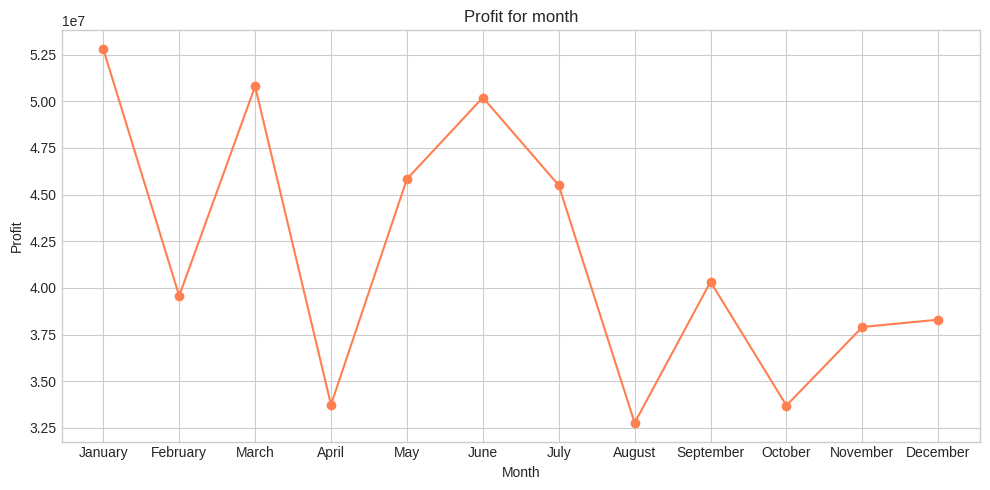

In [ ]:
Orderdate_by_monthyear = sales_total.groupby("month_year")["profit"].sum()

plt.figure(figsize=(10, 5))

plt.plot(Orderdate_by_monthyear.index,Orderdate_by_monthyear.values, marker = "o", color = "coral")
plt.title("Profit for month")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

/tmp/ipykernel_546/2598708939.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table_Mth_Pr_IT= pd.pivot_table(
/tmp/ipykernel_546/2598708939.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Month_by_item=pivot_table_Mth_Pr_IT.groupby("month_year")["Cereal"].sum()
/tmp/ipykernel_546/2598708939.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Month_by_item=pivot_table_Mth_Pr_IT.groupby("month_year")["Household"].sum()
/tmp/ipykernel

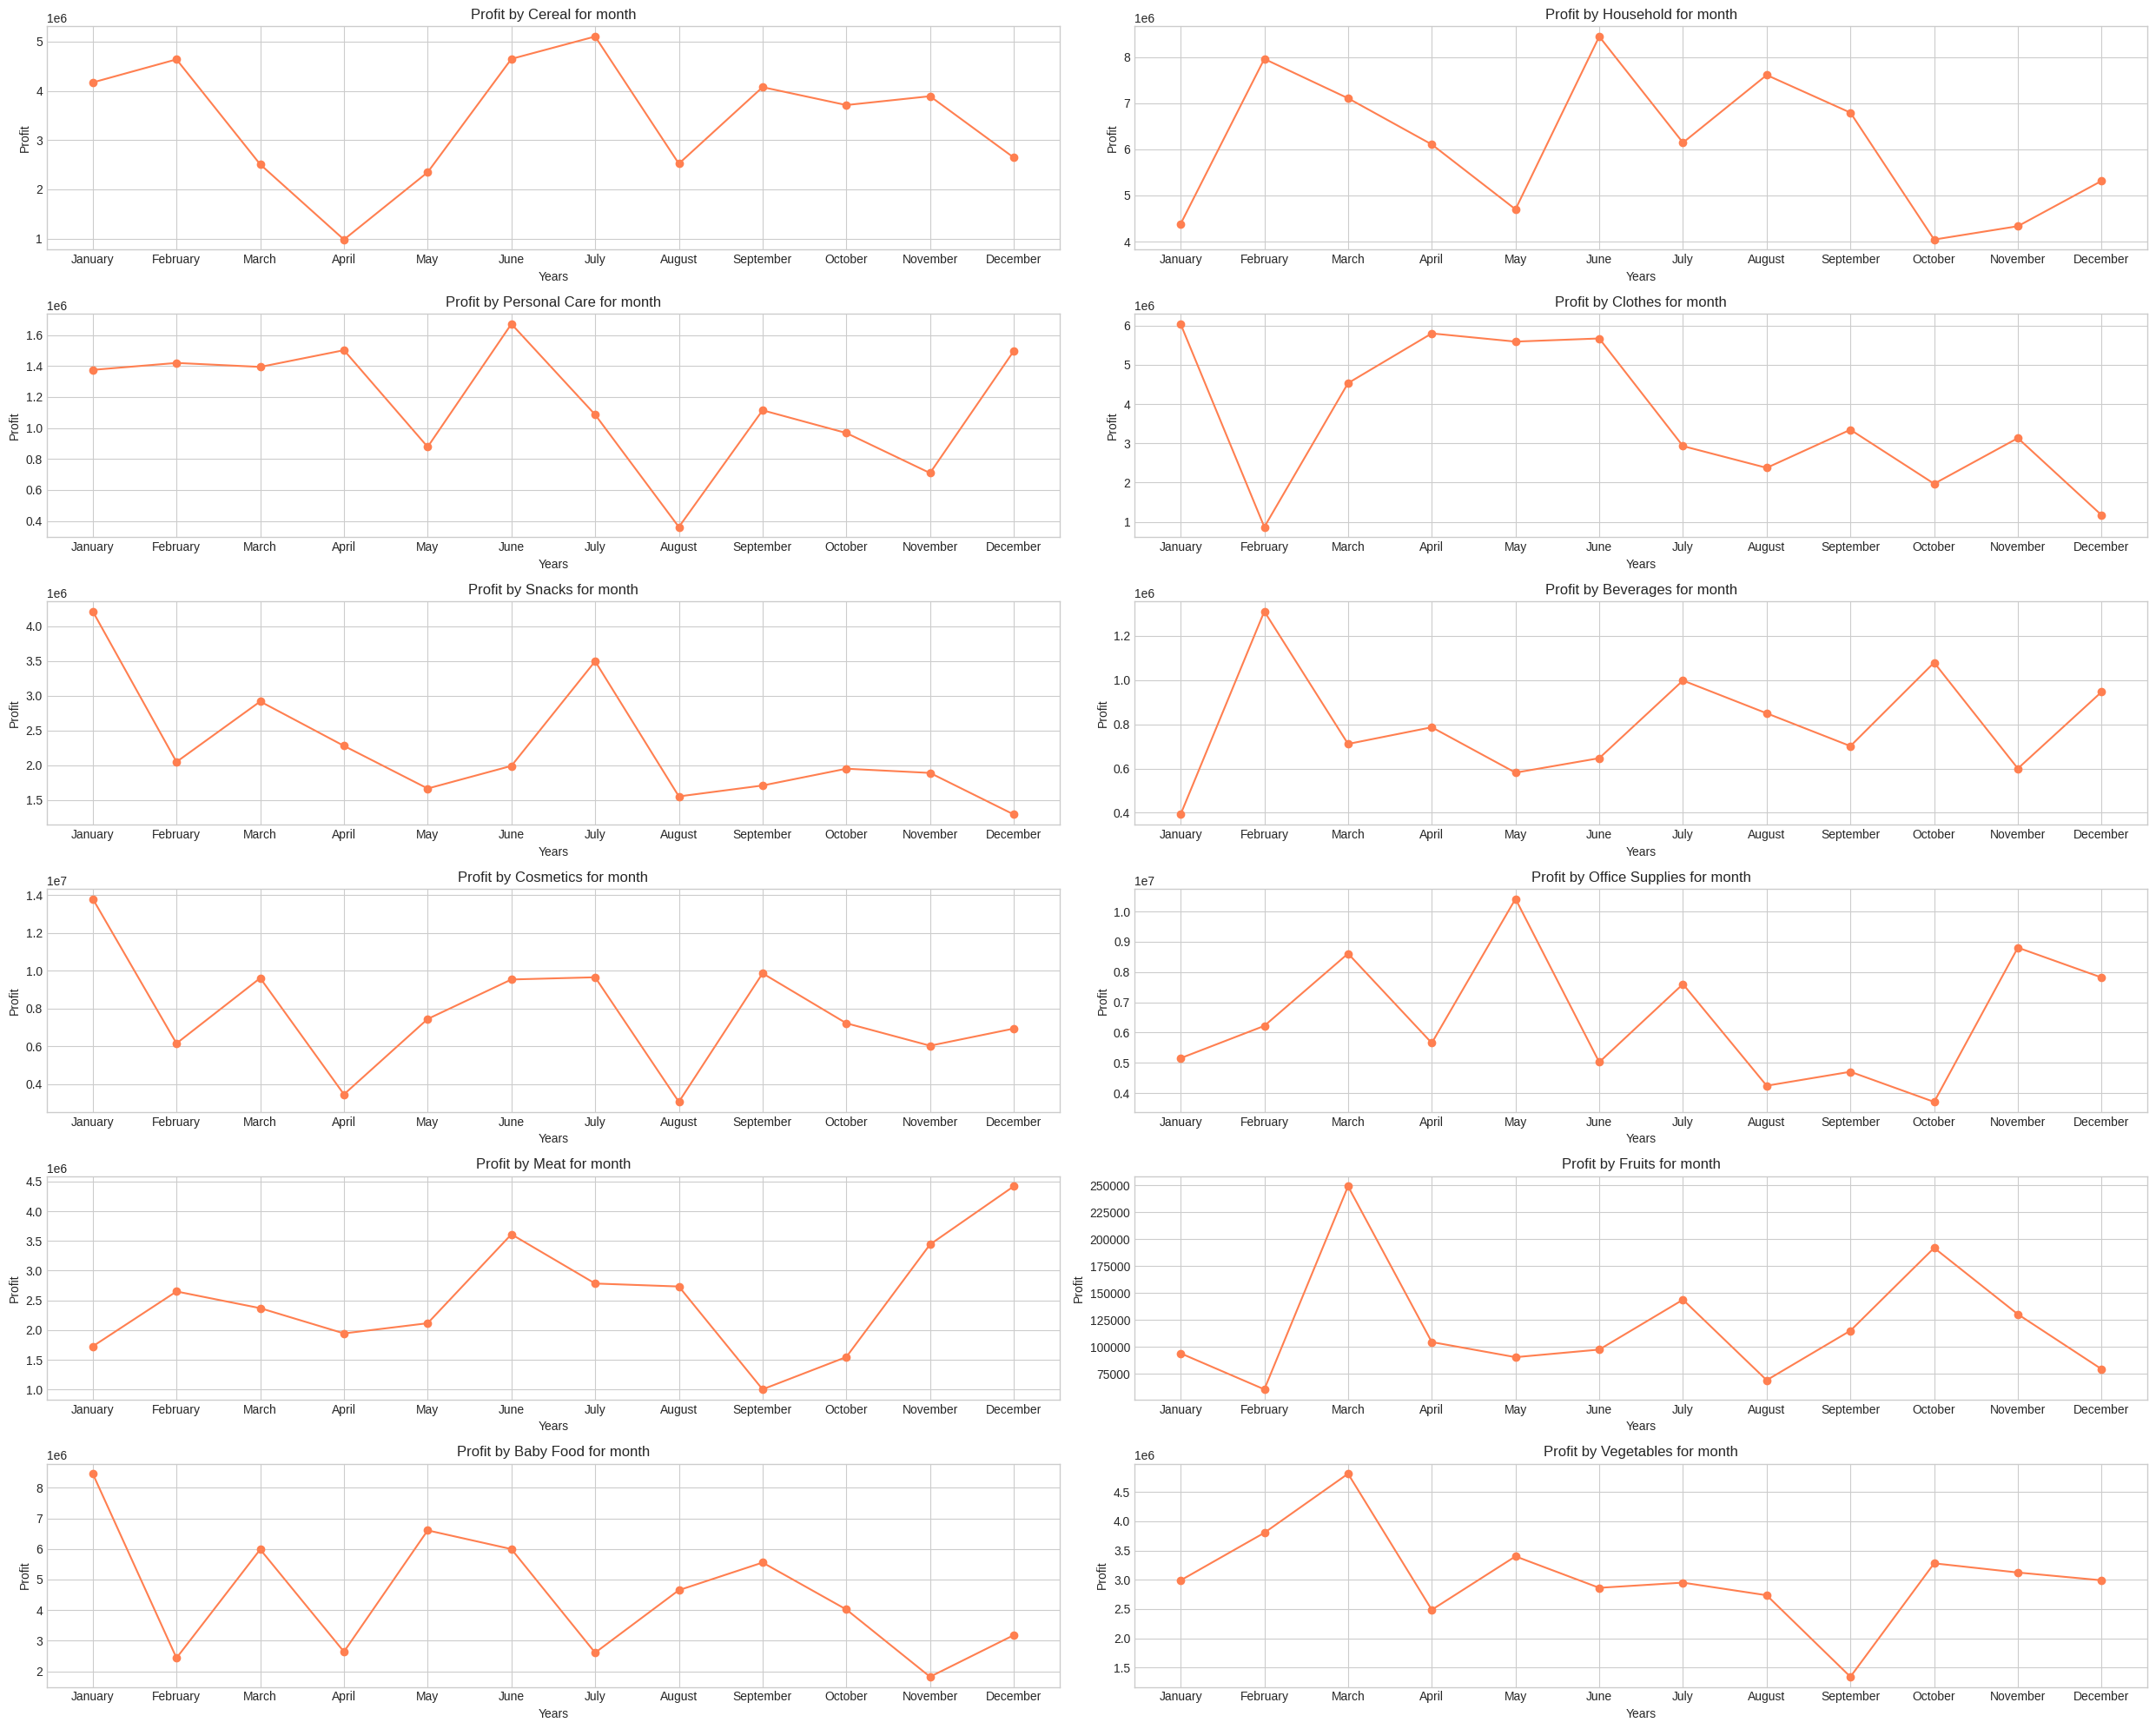

In [ ]:
pivot_table_Mth_Pr_IT= pd.pivot_table(
    sales_total, values="profit", index="month_year", columns="item_type", aggfunc="sum", fill_value=0
)

#Знаходимо всі найменування категорій
sales_total["item_type"].unique()
# array(['Cereal', 'Household', 'Clothes', 'Beverages', 'Office Supplies',
#        'Fruits', 'Vegetables', 'Baby Food', 'Meat', 'Cosmetics', 'Snacks',
#        'Personal Care'], dtype=object)



fig, ax = plt.subplots(6, 2, figsize=(25,20))
# 'Cereal'
Month_by_item=pivot_table_Mth_Pr_IT.groupby("month_year")["Cereal"].sum()
ax[0,0].plot(Month_by_item.index, Month_by_item.values, color="coral", marker = "o")
ax[0,0].set_title("Profit by Cereal for month")
ax[0,0].set_xlabel("Years")
ax[0,0].set_ylabel("Profit")

# 'Household'
Month_by_item=pivot_table_Mth_Pr_IT.groupby("month_year")["Household"].sum()
ax[0,1].plot(Month_by_item.index, Month_by_item.values, color="coral", marker = "o")
ax[0,1].set_title("Profit by Household for month")
ax[0,1].set_xlabel("Years")
ax[0,1].set_ylabel("Profit")

# 'Clothes'
Ord_date_by_item=pivot_table_Mth_Pr_IT.groupby("month_year")["Clothes"].sum()
ax[1,1].plot(Ord_date_by_item.index, Ord_date_by_item.values, color="coral", marker = "o")
ax[1,1].set_title("Profit by Clothes for month")
ax[1,1].set_xlabel("Years")
ax[1,1].set_ylabel("Profit")

# 'Beverages'
Month_by_item=pivot_table_Mth_Pr_IT.groupby("month_year")["Beverages"].sum()
ax[2,1].plot(Month_by_item.index, Month_by_item.values, color="coral", marker = "o")
ax[2,1].set_title("Profit by Beverages for month")
ax[2,1].set_xlabel("Years")
ax[2,1].set_ylabel("Profit")

# 'Office Supplies'
Month_by_item=pivot_table_Mth_Pr_IT.groupby("month_year")["Office Supplies"].sum()
ax[3,1].plot(Month_by_item.index, Month_by_item.values, color="coral", marker = "o")
ax[3,1].set_title("Profit by Office Supplies for month")
ax[3,1].set_xlabel("Years")
ax[3,1].set_ylabel("Profit")

# 'Fruits'
Month_by_item=pivot_table_Mth_Pr_IT.groupby("month_year")["Fruits"].sum()
ax[4,1].plot(Month_by_item.index, Month_by_item.values, color="coral", marker = "o")
ax[4,1].set_title("Profit by Fruits for month")
ax[4,1].set_xlabel("Years")
ax[4,1].set_ylabel("Profit")

# 'Vegetables'
Month_by_item=pivot_table_Mth_Pr_IT.groupby("month_year")["Vegetables"].sum()
ax[5,1].plot(Month_by_item.index, Month_by_item.values, color="coral", marker = "o")
ax[5,1].set_title("Profit by Vegetables for month")
ax[5,1].set_xlabel("Years")
ax[5,1].set_ylabel("Profit")

# 'Baby Food'
Month_by_item=pivot_table_Mth_Pr_IT.groupby("month_year")["Baby Food"].sum()
ax[5,0].plot(Month_by_item.index, Month_by_item.values, color="coral", marker = "o")
ax[5,0].set_title("Profit by Baby Food for month")
ax[5,0].set_xlabel("Years")
ax[5,0].set_ylabel("Profit")

# 'Meat'
Month_by_item=pivot_table_Mth_Pr_IT.groupby("month_year")["Meat"].sum()
ax[4,0].plot(Month_by_item.index, Month_by_item.values, color="coral", marker = "o")
ax[4,0].set_title("Profit by Meat for month")
ax[4,0].set_xlabel("Years")
ax[4,0].set_ylabel("Profit")

# 'Cosmetics'
Month_by_item=pivot_table_Mth_Pr_IT.groupby("month_year")["Cosmetics"].sum()
ax[3,0].plot(Month_by_item.index, Month_by_item.values, color="coral", marker = "o")
ax[3,0].set_title("Profit by Cosmetics for month")
ax[3,0].set_xlabel("Years")
ax[3,0].set_ylabel("Profit")

# 'Snacks'
Month_by_item=pivot_table_Mth_Pr_IT.groupby("month_year")["Snacks"].sum()
ax[2,0].plot(Month_by_item.index, Month_by_item.values, color="coral", marker = "o")
ax[2,0].set_title("Profit by Snacks for month")
ax[2,0].set_xlabel("Years")
ax[2,0].set_ylabel("Profit")

# 'Personal Care'
Month_by_item=pivot_table_Mth_Pr_IT.groupby("month_year")["Personal Care"].sum()
ax[1,0].plot(Month_by_item.index, Month_by_item.values, color="coral", marker = "o")
ax[1,0].set_title("Profit by Personal Care for month")
ax[1,0].set_xlabel("Years")
ax[1,0].set_ylabel("Profit")

plt.tight_layout()
plt.show()

#  Чи можна деякі товари вважати сезонними?

In [ ]:
#Видаляємо непотрібні колонки з нашого датасету
sales_total=sales_total.drop(["day","month"],axis=1)
sales_total.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,...,profit,revenue,country,region_code,region,sub-region,item_type,year,day_week,month_year
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,...,57583.50,133705.00,Norway,NO,Europe,Northern Europe,Cereal,2014,Wednesday,October
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,...,176559.87,409960.10,Serbia,RS,Europe,Southern Europe,Cereal,2016,Thursday,August
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,...,777770.89,3136191.11,NaN,NaN,NaN,NaN,Household,2014,Friday,July
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,...,85998.24,127966.88,Montenegro,ME,Europe,Southern Europe,Clothes,2017,Saturday,May
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,...,119767.68,362897.60,Serbia,RS,Europe,Southern Europe,Beverages,2012,Saturday,August


#Проведено аналіз датасету продажів товарів за період 2011-2017 років.
#Після очистки, нормалізації інформації у таблицях, маємо датасет на 1328 замовлень (665 замовлень оффлайн та 663 замовлення онлайн), з загальною сумою доходу(revenue) – 1 702 129 408.21, з загальним прибутком (profit)–  501 434 459.0, що становить 29.46 % від виручки. Замовленнями охоплено 46 країн з 2 континентів з середнім прибутком на одне замовлення – 377 586.19.

#За найбільшим прибутком можна виділити:
-	топ-5 країн: Andora, Ukraine, Malta, San Marino, Hungary;
-	топ-5 категорій товарів: Cosmetics, Office Supplies, Household, Baby food, Clothes.

#За найбільшим доходом:
-	топ-5 країн: Сzech Republic, Ukraine, Bosnia and Herzegovina, Macedonia, San Marino;
-	топ-5 категорій товарів: Office Supplies, Household, Cosmetics, Meat, Baby food.
#За популярністю (найбільшою кількістю проданих одиниць товарів):
-	топ-5 країн: Macedonia, San Marino, Andorra, Greece, Malta.
-	топ-5 категорій товарів: Office Supplies, Beverages, Fruits, Clothes, Vegetables.

#Аналізуючи графік залежності прибутку від термінів обробки замовлення, можна виключити той факт, що прибуток зростає або зменшується від термінів обробки замовлення. Найшвидше обробляються замовлення в Croatia, UK, Denmark, Estonia та Serbia, найдовше – Hungary, Georgia, Austria, Slovakia та Luxembourg. Найшвидше відвантажуються товари категорії Personal Care, Clothes, Vegetables, Household, Beverages та Fruits, а найдовше – Cereal, Office Supplies, Baby food, Cosmetics, Meat та Snacks.
#Починаючи з 01.01.2014 можна побачити чіткі піки прибутків у березні 2014, серпні 2014, листопаді 2015, липні 2016 і невеликим піком у травні 2015 та липні 2017. Спад прибутків можна спостерігати у лютому 2014, з жовтня по грудень 2014, липні 2015, липні 2016. Зробити чіткі висновки щодо залежності загального прибутку від сезону чи року в розрізі неможливо, тому потрібно провести більш детальний аналіз в розрізі категорій або країн.


##«Cereal»
Протягом тижня ми спостерігаємо зріст прибутку, а й відповідно й попиту, починаючи з п’ятниці. Пік прибутку ми спостерігаємо у суботу, а мінімум продажів у понеділок, з вівторка по п’ятницю спостерігаємо стабільний прибуток.
У розрізі місяців піки прибутків приходяться на лютий, червень та липень, з подальшим спадом. Протягом осінніх місяців ми бачимо коливання прибутку, але він більший за середнє значення. Найменший прибуток за цією категорією можна спостерігати у весняні з найнижчим прибутком в квітні місяці.
Підсумовуючи можна сказати, що найбільший попит і відповідно продажі цієї категорії товарів спостерігається у суботу та протягом літнього періоду.

##«Household»
Для цієї категорії ми бачимо 2 великих піки прибутку у понеділок та середу, найменший прибуток у вівторок. В інші дні тижня прибуток коливається від більшого до меншого.
Найбільші піки прибутку спостерігаються у лютому та червні місяці, після чого можна візуалізувати спад прибутку з подальшим підвищенням без виходу у пік. Найгірші та найменші прибутки від продажів спостерігаються в останні два місяці осені з невеликим підвищенням в грудні.
Враховуючи вищезазначене спостерігаємо коливання продажів протягом всього періоду аналізу. Виділити сезонність популярності товарів даної категорії неможливо, через постійні коливання прибутку.

##Personal Care'
Яскраво виражені піки прибутку у четвер та суботу, які поступово переходять у спад понеділка та п’ятниці, можна спостерігати для категорії «Personal Care».
Протягом грудня-квітня можна спостерігати стабільний високий прибуток товарів даної категорії, що свідчить про сезонність товару і великий попит на товари. Хоча і в травні спостерігається спад прибутку, все одно загальний прибуток становить вище середнього для цієї категорії. Після піку у літні місяці в серпні відбувається різке зниження прибутку і найменше значення за весь рік.
Сезон продажу даної категорії товару – грудень- квітень.

##«Clothes»
У категорії «Clothes» ми бачимо великі коливання прибутку від найменшого до найбільшого, від піку до спаду протягом всього тижня.
Найбільший пік прибутку спостерігається, який переходить в стрімкий спад до найнижчого показника в лютому місяці, після чого відбувається стрімке підвищення прибутку з виходом у пік в квітні-червні, після цього відбувається спад з коливаннями прибутку нижчим за середнє.

##«Snacks»
Протягом всього тижня ми бачимо невеликий прибуток від продажів цієї категорії з переходом у пік продажів з суботи до понеділка.
Для цієї категорії товарів спостерігається коливання прибутку протягом року, але нижчому за середнє значення. Піки прибутку припадають на січень та липень з різкими спадами до мінімальних значень.

##«Beverages»
Категорія «Beverages» має два піки прибутку у понеділок та суботу, а найменший прибуток у п’ятницю, в інші дні тижня ми бачимо незначні коливання після спаду піків. Якщо дивитися в розрізі місяців, то пік прибутку припадає на лютий, а потім відбувається коливання прибутку в межах середнього для цієї категорії.

##«Cosmetics»
Можна спостерігати коливання прибутку цієї категорії протягом всього тижня з ярко вираженим піком прибутку в п’ятницю.
Аналізуючи графік прибутку по місяцях в розрізі категорії «Cosmetics» можна візуалізувати пік продажів у січні зі стрімким спадом у лютому, після цього відбувається коливання прибутку з виходом у найменший прибуток у квітні місяці. В період травень-липень спостерігається стабілізація прибутку з різким спадом у серпні.

##«Office Supplies»
Прибуток цієї категорії коливається в межах середнього прибутку з піками прибутку у п’ятницю та неділю і найменшим прибутком у суботу.
Коливання прибутку протягом року можна спостерігати на графіку, що свідчить про відсутність сезонності для категорії та періодичний попит на продукцію цієї категорії.

##«Meat»
Починаючи від піку прибутку у понеділок ми бачимо поступовий спад до мінімального прибутку у п’ятницю з переходом у невеликий пік прибутку, розміром з середній прибуток, та подальшим спадом у неділю.
Підвищення прибутку спостерігається з жовтня по грудень. В інші місяці року відбувається коливання прибутку з переходом у найнижче значення у вересні місяці.

##«Fruits»
Починаючи з п’ятниці ми бачимо зростання прибутку включно по понеділок з різким спадом у вівторок.
Графік залежності прибутку від місяця по даній категорії має два ярко виражені піки у березні та жовтні, в інші місяці року спостерігається коливання прибутку нижчому за середні показники для «Fruits».

##«Baby Food»
Продукти категорії «Baby Food» поступово підвищуються від найнижчого значення прибутку у понеділок до піку у неділю з невеликим просіданням прибутку у вівторок.
Графік відображає коливання прибутку для цієї категорії з незначними піками в межах середнього значення прибутку. Можна виділити один найбільший пік прибутку в січні та найменший прибуток у листопаді.

##«Vegetables»
Прибуток цієї категорії є значний пік прибутку у неділю та трохи менший пік у середині тижня, а саме у середу. Після цих піків ми можемо побачити спад прибуку до мінімального значення.
Протягом періоду, який підпадає під аналіз, можна виділити підвищення прибутку з січня по березень, після чого відбувається спад прибутку та його коливання до вересня (найнижчий показник за рік).  

#В розрізі років маємо наступну статистику.

##2011 рік був успішний для категорій «Cereal», «Meat» та країн: «Andora», «Greece», «Russia», «Hungary». Загальний прибуток склав 69 044 659.73

##2012 рік – для: «Cereal», «Vegetables» та країн: «Ukraine», «Malta», «Czech Republic». Загальний прибуток склав 87 884 066.44

##2013 рік – для: «Household», «Clothes», «Snacks»,«Cosmetics», «Meat», «Baby Food», «Vegetables» та країн: «Andora», «Ukraine», «Greece», «Malta», «Herzegovina», «San Marino». Загальний прибуток склав 53 387 995.18

##2014 рік – для: «Cereal», «Snacks». Загальний прибуток склав 71 189 625.60

##2015 рік – для: «Household», «Personal Care», «Clothes» та країн «Russia», «Hungary», «Czech Republic». Загальний прибуток склав 61 734 039.82

##2016 рік – для: «Household», «Beverages», «Office Supplies» та країн: «Malta», «Herzegovina», «Macedonia». Загальний прибуток склав 57 771 920.85

##2017 рік – для: «Clothes», «Fruits», «Vegetables» та країн «Andora», «San Marino». Загальний прибуток склав 38 999 691.48

#Найбільш прибутковим був 2012 рік, а найменш – 2013. 2017 має найменший прибуток, але для аналізу були взяті дані лише за 7 місяців. Найбільший прибуток в розрізі місяців у січні, березні та червні, найменший – квітень, серпень, серпень.



In [ ]:
pivot_table_Od_Pr_Cntr= pd.pivot_table(
    sales_total, values="profit", index="order_date", columns="country", aggfunc="sum", fill_value=0
)
pivot_table_Od_Pr_Cntr_by_year = pivot_table_Od_Pr_Cntr.resample('Y').sum()

pivot_table_Od_Pr_Cntr_by_year.head()

/tmp/ipykernel_546/3041450140.py:4: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  pivot_table_Od_Pr_Cntr_by_year = pivot_table_Od_Pr_Cntr.resample('Y').sum()


country,Albania,Andorra,Armenia,Austria,Belarus,Belgium,Bosnia and Herzegovina,Bulgaria,Croatia,Cyprus,...,Russia,San Marino,Serbia,Slovakia,Slovenia,Spain,Sweden,Switzerland,Ukraine,United Kingdom
order_date,,,,,,,,,,,,,,,,,,,,,
2010-12-31,2733094.76,3243222.41,1930234.67,3489734.81,773377.19,470013.36,407978.70,3159778.90,692824.10,432723.11,...,2933514.99,467794.78,771497.78,566207.56,1457975.91,1890557.31,3315255.50,1666975.80,840103.28,957009.89
2011-12-31,1593784.75,677799.93,903658.36,839535.12,1875224.26,770912.38,748347.82,394048.32,19133.58,450242.22,...,2129811.50,699193.28,1980187.03,1025976.10,115946.64,2267788.73,2039984.49,681156.00,3598514.69,657019.62
2012-12-31,1805447.26,3423332.26,1179933.37,210537.95,1872339.31,1012374.70,5708297.00,2422474.88,1959755.71,3015072.06,...,383744.07,3291909.78,1002075.04,3212656.55,1919570.29,834306.78,2219364.70,1787863.14,3732033.07,3166539.27
2013-12-31,108212.64,1205156.65,415253.58,651535.22,1102328.72,654942.94,1274603.57,259786.52,3243433.04,2188047.69,...,1823589.11,1576276.91,3066301.52,1583101.34,1905404.18,657056.76,989680.97,294436.82,113863.86,684764.50
2014-12-31,81133.66,1028468.14,964283.24,1056415.09,904792.84,659139.37,130215.62,1670323.72,364115.52,2319944.20,...,2920495.73,1886580.33,2136539.23,1010312.88,2490814.99,0.00,0.00,3354692.69,2163209.64,0.00
